# HỆ THỐNG PHÁT HIỆN GIAO DỊCH TÀI CHÍNH BẤT THƯỜNG VÀ NGHI VẤN GIAN LẬN

## Mục tiêu

Đồ án xây dựng một mô hình học máy (Machine Learning) có khả năng phân loại một giao dịch tài chính thành hai nhóm:

- **0 – Giao dịch hợp lệ:** giao dịch bình thường.
- **1 – Giao dịch gian lận (Fraud):** giao dịch có dấu hiệu bất thường và cần được kiểm tra.

Quy trình thực hiện gồm các bước chính:

1. Nạp và tìm hiểu dữ liệu.
2. Làm sạch dữ liệu.
3. Khám phá dữ liệu để tìm các đặc điểm đáng chú ý.
4. Tạo các đặc trưng phục vụ cho mô hình.
5. Chia dữ liệu thành tập Train và Test.
6. Xử lý giá trị bất thường và chuẩn hóa dữ liệu.
7. Huấn luyện và tinh chỉnh các mô hình (Random Forest, XGBoost, LightGBM, CatBoost, Stacking).
8. Đánh giá và so sánh các mô hình trên tập Test.
9. Kiểm tra độ ổn định qua nhiều lần chia dữ liệu.
10. Đưa ra mô hình đề xuất cuối cùng.

Trong bài toán phát hiện gian lận, số giao dịch gian lận thường rất ít so với giao dịch bình thường. Vì vậy, đồ án không chỉ nhìn vào Accuracy mà tập trung nhiều hơn vào khả năng phát hiện đúng các giao dịch gian lận.




## Chuẩn bị thư viện

Ở bước này, các thư viện cần thiết được nạp để phục vụ cho toàn bộ quá trình xử lý dữ liệu và xây dựng mô hình.

Một số thư viện chính:

- **Pandas:** đọc và xử lý dữ liệu dạng bảng.
- **NumPy:** hỗ trợ các phép tính số học.
- **Matplotlib / Seaborn:** dùng để trực quan hóa dữ liệu.
- **Scikit-learn:** cung cấp các công cụ chia dữ liệu, chuẩn hóa, xây dựng Random Forest và tính các chỉ số đánh giá.
- **XGBoost:** dùng để xây dựng mô hình XGBoost.

Các thư viện này chỉ là công cụ hỗ trợ. Phần xử lý và đánh giá mô hình sẽ được thực hiện ở các bước phía sau.

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
os.environ['PYTHONWARNINGS'] = 'ignore'  # chặn warning tràn ngập (gây phình notebook)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, fbeta_score,
    confusion_matrix, roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from scipy.stats import chi2_contingency
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
from imblearn.over_sampling import SMOTE, ADASYN

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## Nạp dữ liệu

Dữ liệu giao dịch được đọc vào chương trình và lưu trong biến `df`.

Sau khi đọc dữ liệu, một bản sao có tên `df_raw` được tạo ra để giữ lại dữ liệu ban đầu. Bản này sẽ không bị chỉnh sửa và được dùng để đối chiếu khi cần.

Hai khái niệm cần chú ý:

- **Dòng (row):** tương ứng với một giao dịch.
- **Cột (column):** tương ứng với một thông tin của giao dịch, ví dụ số tiền, thời gian, loại dịch vụ hoặc nhãn gian lận.

Đề bài yêu cầu tối thiểu 500 giao dịch, vì vậy chương trình kiểm tra điều kiện này ngay sau khi đọc dữ liệu.


In [ ]:
# ============================ DATA LOADING =============================
# Mục tiêu: nạp dữ liệu nguồn, kiểm tra quy mô tối thiểu và giữ một bản sao
# nguyên trạng để báo cáo missing/duplicate trước khi cleaning.
sheet_id = "1ByffoXqSwnG8qHj4zaSkiO7hIIQS-43fR5mY8aquWnE"
gid = "701522832"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
df = pd.read_csv(url)
df_raw = df.copy(deep=True)

print(f"Số mẫu: {df.shape[0]} | Số cột: {df.shape[1]}")
assert df.shape[0] >= 500, "Chưa đạt tối thiểu 500 mẫu theo yêu cầu đồ án"
df

Số mẫu: 30058 | Số cột: 23


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,6/21/2020 12:14,2.290000e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,339.659,-809.355,333497,Mechanical engineer,3/19/1968,2da90c7d74bd46a0caf3777415b3ebd3,1.370000e+09,3.398.639,-812.007,0
1,1,6/21/2020 12:14,3.570000e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,403.207,-110.436,302,"Sales professional, IT",1/17/1990,324cc204407e99f51b0d6ca0055005e7,1.370000e+09,394.505,-109.960,0
2,2,6/21/2020 12:14,3.600000e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,406.729,-735.365,34496,"Librarian, public",10/21/1970,c81755dbbbea9d5c77f094348a7579be,1.370000e+09,4.049.581,-741.961,0
3,3,6/21/2020 12:15,3.590000e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,285.697,-808.191,54767,Set designer,7/25/1987,2159175b9efe66dc301f149d3d5abf8c,1.370000e+09,288.124,-808.831,0
4,4,6/21/2020 12:15,3.530000e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,442.529,-85.017,1126,Furniture designer,7/6/1955,57ff021bd3f328f8738bb535c302a31b,1.370000e+09,4.495.915,-858.847,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30053,30053,6/30/2020 23:59,4.200000e+12,fraud_Dickinson Ltd,misc_pos,1.76,Christie,Williamson,F,519 Jerry Views,...,414.768,-953.509,2036,Engineering geologist,8/20/1971,e7ae31c76224c62ffc4475f636afa934,1.370000e+09,4.234.161,-949.102,0
30054,30054,6/30/2020 23:59,4.190000e+12,"fraud_Prosacco, Kreiger and Kovacek",home,102.23,Casey,Howell,F,374 Christopher Ramp Suite 855,...,333.645,-812.718,4913,Technical brewer,11/10/1966,03bfbd75196d55a70f82d2ca0e57eecd,1.370000e+09,3.370.465,-810.943,0
30055,30055,6/30/2020 23:59,4.430000e+12,"fraud_McLaughlin, Armstrong and Koepp",travel,5.81,Michelle,Rodriguez,F,1742 Brandon Squares Apt. 461,...,333.305,-105.693,8874,Licensed conveyancer,8/16/2000,8d95e450457daf38b4754839ebc3602b,1.370000e+09,3.329.562,-104.810,0
30056,30056,6/30/2020 23:59,4.990000e+18,fraud_Romaguera Ltd,health_fitness,4.53,Benjamin,Kim,M,920 Patrick Light,...,41.173,-892.187,532,Audiological scientist,1/9/1956,ac801c564851bdb78d526fb489027c1b,1.370000e+09,4.097.826,-887.256,0


## 1. Tìm hiểu dữ liệu và Phân loại

Trước khi xây dựng mô hình, cần hiểu dữ liệu đang có những thông tin gì và tỷ lệ gian lận trong dữ liệu là bao nhiêu.

Ở bước này, chương trình kiểm tra:

- Số lượng giao dịch và số lượng cột.
- Kiểu dữ liệu của từng cột.
- Có giá trị bị thiếu hay không.
- Số lượng giao dịch bình thường và gian lận.

### Nhãn `is_fraud`

Đây là giá trị mà mô hình cần học để dự đoán:

- `is_fraud = 0`: giao dịch bình thường.
- `is_fraud = 1`: giao dịch gian lận.

Nếu số giao dịch của hai nhóm chênh lệch quá lớn thì dữ liệu được gọi là **mất cân bằng (imbalanced data)**.

Ví dụ, nếu có rất nhiều giao dịch bình thường nhưng chỉ có một số ít fraud, một mô hình chỉ đo bằng độ chính xác (Accuracy) có thể cho điểm rất cao nhưng vẫn bỏ sót phần lớn giao dịch gian lận. Vì vậy, ở các bước sau sẽ dùng thêm các chỉ số Recall, Precision, F1-Score, F2-Score, ROC-AUC và PR-AUC.


In [ ]:
# ========================= 1. DATA UNDERSTANDING =========================
print("MỤC TIÊU: hiểu quy mô, kiểu dữ liệu và tỷ lệ fraud của dataset.")
number_of_rows, number_of_columns = df_raw.shape
print(f"1. Dataset có {number_of_rows:,} giao dịch và {number_of_columns} cột.")
# Mỗi cột đang có kiểu dữ liệu gì và có giá trị thiếu không?

data_info = pd.DataFrame(
    {
        "Kiểu dữ liệu": df_raw.dtypes.astype(str),
        "Số giá trị có dữ liệu": df_raw.notna().sum(),
        "Số giá trị thiếu": df_raw.isna().sum(),
    }
)
display(data_info)
# is_fraud là nhãn cần dự đoán: 0 = hợp lệ, 1 = gian lận.
label_col = "is_fraud"
label_counts = df_raw[label_col].value_counts(dropna=False).sort_index()
label_percent = label_counts / label_counts.sum() * 100
label_summary = pd.DataFrame(
    {"Số giao dịch": label_counts, "Tỷ lệ (%)": label_percent.round(2)}
)
print("2. Phân bố nhãn cần dự đoán:")
display(label_summary)
fraud_rate = label_percent.get(1, 0)
class_ratio = (
    label_counts.max() / label_counts.min() if len(label_counts) > 1 else np.nan
)
print(
    f"Kết luận: fraud chiếm {fraud_rate:.2f}% và non-fraud chiếm {100 - fraud_rate:.2f}%. "
    f"Lớp lớn gấp khoảng {class_ratio:.2f} lần lớp nhỏ."
)
if class_ratio >= 3:
    print(
        "Dataset bị mất cân bằng rõ rệt, vì vậy không dùng Accuracy làm tiêu chí chính."
    )
else:
    print("Dataset chưa bị mất cân bằng nghiêm trọng.")

MỤC TIÊU: hiểu quy mô, kiểu dữ liệu và tỷ lệ fraud của dataset.
1. Dataset có 30,058 giao dịch và 23 cột.


,Kiểu dữ liệu,Số giá trị có dữ liệu,Số giá trị thiếu
Unnamed: 0,int64,30058,0
trans_date_trans_time,object,30058,0
cc_num,float64,30058,0
merchant,object,30058,0
category,object,30058,0
amt,float64,30058,0
first,object,30058,0
last,object,30058,0
gender,object,30058,0
street,object,30058,0


2. Phân bố nhãn cần dự đoán:


,Số giao dịch,Tỷ lệ (%)
is_fraud,,
0,29925,99.56
1,133,0.44


Kết luận: fraud chiếm 0.44% và non-fraud chiếm 99.56%. Lớp lớn gấp khoảng 225.00 lần lớp nhỏ.
Dataset bị mất cân bằng rõ rệt, vì vậy không dùng Accuracy làm tiêu chí chính.


## 2. Làm sạch dữ liệu – Data Cleaning

Dữ liệu thực tế có thể chứa dòng bị lặp, sai kiểu dữ liệu hoặc thiếu thông tin. Những vấn đề này cần được xử lý trước khi đưa dữ liệu vào mô hình.

Trong bước này thực hiện:

1. **Kiểm tra dòng trùng:** nếu một giao dịch bị lặp hoàn toàn thì chỉ giữ lại một dòng.
2. **Chuyển dữ liệu số:** các cột như số tiền và tọa độ được chuyển về dạng số để có thể tính toán.
3. **Chuyển thời gian:** thời điểm giao dịch được đưa về định dạng ngày giờ.
4. **Kiểm tra dữ liệu thiếu:** những giao dịch thiếu các thông tin bắt buộc sẽ được phát hiện và xử lý.

Một số ký hiệu:

- `amt`: số tiền của giao dịch.
- `lat`: vĩ độ.
- `long`: kinh độ.
- `trans_date_trans_time`: thời điểm giao dịch.
- `cc_num`: mã thẻ.
- `category`: loại hình dịch vụ.
- `is_fraud`: nhãn cho biết giao dịch có gian lận hay không.

Sau bước này, dữ liệu đủ sạch để tiếp tục phân tích.

In [ ]:
# ========================= 2. DATA CLEANING =========================
print('MỤC TIÊU: sửa các lỗi dữ liệu cơ bản trước khi phân tích.')

# Bước 1: bỏ các dòng trùng hoàn toàn.
df = df_raw.copy(deep=True)
duplicate_count = int(df.duplicated().sum())
df = df.drop_duplicates().copy()
print(f'1. Đã loại {duplicate_count} dòng trùng; còn {len(df):,} dòng.')

# Bước 2: đổi các cột số đang có thể chứa ký tự hoặc dấu phân cách về float.
def convert_to_number(value):
    if pd.isna(value):
        return np.nan
    text = re.sub(r'[^\d.,-]', '', str(value).strip())
    if not text or text in {'-', '.', ','}:
        return np.nan
    if '.' in text and ',' in text:
        text = (
            text.replace(',', '')
            if text.rfind('.') > text.rfind(',')
            else text.replace('.', '').replace(',', '.')
        )
    elif ',' in text:
        text = text.replace(',', '') if text.count(',') > 1 else text.replace(',', '.')
    elif text.count('.') > 1:
        text = text.replace('.', '')
    try:
        return float(text)
    except ValueError:
        return np.nan

for column in ['lat', 'long', 'amt', 'merch_lat', 'merch_long']:
    df[column] = df[column].apply(convert_to_number)
print('2. Đã chuyển lat, long và amt về dạng số.')

# Bước 3: đổi thời gian về datetime để có thể lấy giờ/thứ.
df['trans_date_trans_time'] = pd.to_datetime(
    df['trans_date_trans_time'], errors='coerce'
 )
print('3. Đã chuyển trans_date_trans_time về dạng thời gian.')

# Bước 4: kiểm tra và loại dòng thiếu dữ liệu bắt buộc.
required_columns = [
    'lat', 'long', 'amt', 'trans_date_trans_time',
    'cc_num', 'category', 'is_fraud'
 ]
missing_summary = df[required_columns].isna().sum()
missing_rows = int(df[required_columns].isna().any(axis=1).sum())
print(f'4. Có {missing_rows:,} dòng thiếu ít nhất một cột bắt buộc.')
if missing_rows > 0:
    display(missing_summary[missing_summary > 0])
    df = df.dropna(subset=required_columns).copy()
else:
    print('Không có dòng thiếu dữ liệu bắt buộc.')

print(f'Kết quả sau cleaning: còn {len(df):,} dòng để phân tích.')

MỤC TIÊU: sửa các lỗi dữ liệu cơ bản trước khi phân tích.
1. Đã loại 0 dòng trùng; còn 30,058 dòng.
2. Đã chuyển lat, long và amt về dạng số.
3. Đã chuyển trans_date_trans_time về dạng thời gian.
4. Có 0 dòng thiếu ít nhất một cột bắt buộc.
Không có dòng thiếu dữ liệu bắt buộc.
Kết quả sau cleaning: còn 30,058 dòng để phân tích.


## 3. Khám phá dữ liệu – EDA

EDA là bước quan sát dữ liệu để tìm ra những đặc điểm có thể liên quan đến gian lận.

Ở phần này, dữ liệu chưa được dùng để huấn luyện mô hình. Mục tiêu chủ yếu là xem những thông tin nào có thể hữu ích và quyết định đặc trưng (feature) nào nên được giữ lại.

### 3.1 Kiểm tra các đặc trưng giao dịch

Một số đặc trưng (feature) được tạo thêm để quan sát hành vi giao dịch:

- `amt`: số tiền giao dịch.
- `txn_freq_hour`: số lần cùng một thẻ giao dịch trong một giờ.
- `distance_km`: khoảng cách giữa giao dịch hiện tại và giao dịch trước của cùng thẻ, được tính từ tọa độ của hai giao dịch liên tiếp. Khoảng cách lớn trong thời gian ngắn có thể là một dấu hiệu bất thường.





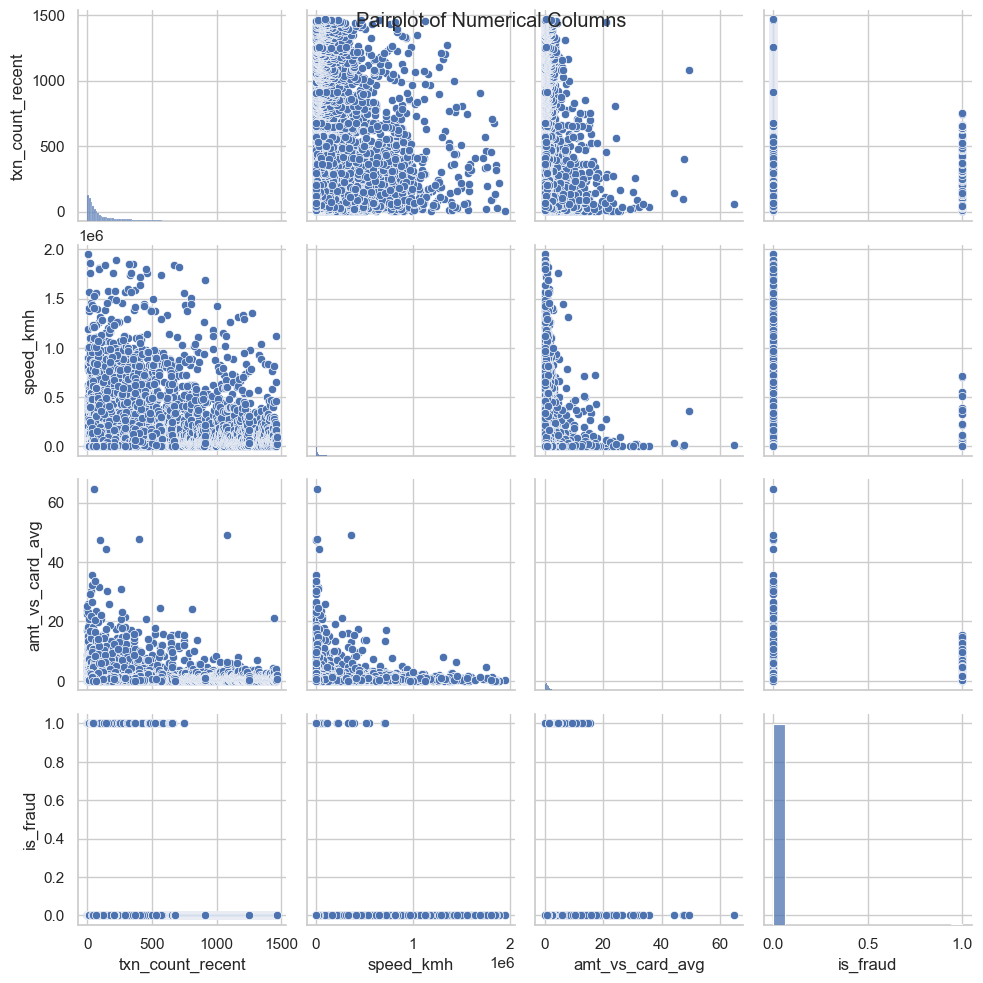

In [ ]:
import seaborn as sns
from itertools import combinations

def calculate_distance(lat1, lon1, lat2, lon2):
    earth_radius_km = 6371.0
    latitude_difference = np.radians(lat2 - lat1)
    longitude_difference = np.radians(lon2 - lon1)
    area = (
        np.sin(latitude_difference / 2) ** 2
        + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2))
        * np.sin(longitude_difference / 2) ** 2
    )
    return earth_radius_km * 2 * np.arctan2(
        np.sqrt(area), np.sqrt(1 - area)
    )

eda_df = df.copy()
eda_df['hour'] = eda_df['trans_date_trans_time'].dt.hour
eda_df['txn_freq_hour'] = eda_df.groupby(['cc_num', 'hour'])['hour'].transform('count')
previous_latitude = eda_df.groupby('cc_num')['lat'].shift(1)
previous_longitude = eda_df.groupby('cc_num')['long'].shift(1)
eda_df['distance_km'] = calculate_distance(
    eda_df['lat'], eda_df['long'],
    previous_latitude, previous_longitude
).fillna(0)

# --- Các đặc trưng gốc ---
eda_df['age'] = (
    eda_df['trans_date_trans_time'].dt.year
    - pd.to_datetime(eda_df['dob'], errors='coerce').dt.year
)
eda_df['category_freq_card'] = eda_df.groupby(['cc_num', 'category'])['category'].transform('count')
eda_df['txn_count_card'] = eda_df.groupby('cc_num')['trans_num'].transform('count')
eda_df['amt_vs_card_median'] = (
    eda_df['amt'] - eda_df.groupby('cc_num')['amt'].transform('median')
)

# --- Features bổ sung để cải thiện model ---
# 1. Log amount — giam anh huong outliers
eda_df['amt_log'] = np.log1p(eda_df['amt'])

# 2. Z-score của amount theo từng card — biết giao dịch này bất thường so với trung bình card
card_amt_mean = eda_df.groupby('cc_num')['amt'].transform('mean')
card_amt_std = eda_df.groupby('cc_num')['amt'].transform('std').fillna(1)
eda_df['amt_zscore_card'] = (eda_df['amt'] - card_amt_mean) / card_amt_std

# 3. Có phải giao dịch đêm không? (22h - 5h)
eda_df['is_night'] = eda_df['hour'].apply(lambda h: 1 if h >= 22 or h < 5 else 0).astype(int)

# 4. khoảng cách / thời gian giữa 2 giao dịch
time_diff_hours = eda_df.groupby('cc_num')['trans_date_trans_time'].diff().dt.total_seconds().fillna(3600) / 3600
eda_df['speed_kmh'] = eda_df['distance_km'] / time_diff_hours.clip(lower=0.01)

# 5. Tỉ lệ số tiền với khoảng cách
eda_df['amt_per_km'] = eda_df['amt'] / eda_df['distance_km'].clip(lower=0.01)

# 6. Tần suất giao dịch — số giao dịch gần đây của từng card
eda_df['txn_count_recent'] = eda_df.groupby('cc_num')['trans_num'].transform('cumcount') + 1

# 7. So sánh amount với trung bình của card
eda_df['amt_vs_card_avg'] = eda_df['amt'] / eda_df.groupby('cc_num')['amt'].transform('mean').clip(lower=0.01)

# Pairplot to visualize relationships between numerical columns
sns.pairplot(eda_df[['txn_count_recent', 'speed_kmh', 'amt_vs_card_avg', 'is_fraud']])
plt.suptitle('Pairplot of Numerical Columns')
plt.show()



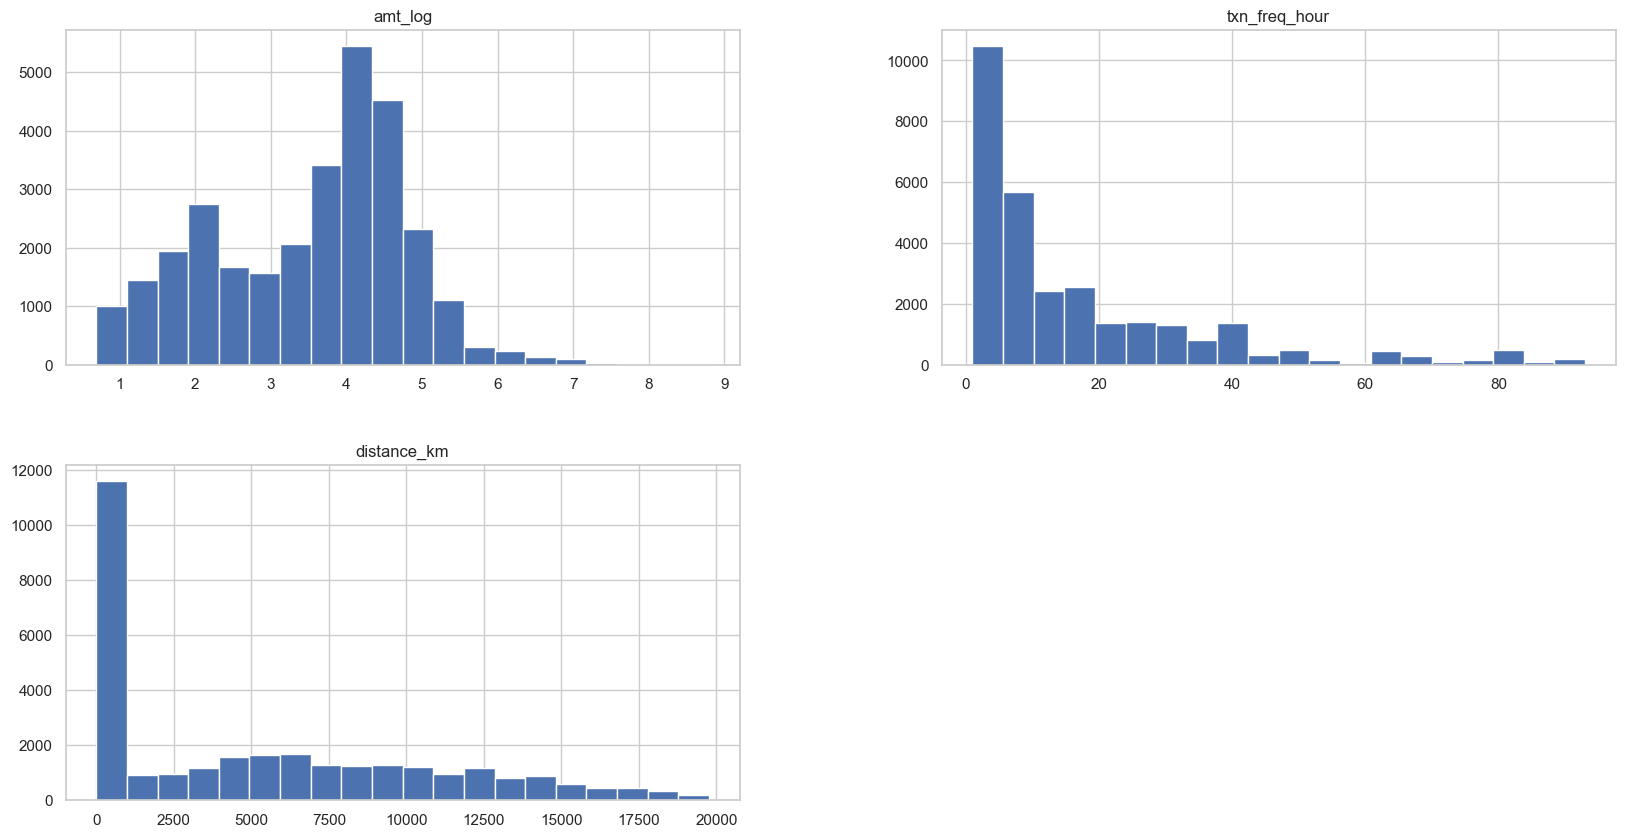

In [ ]:
# phân bố dữ liệu
eda_df[['amt_log', 'txn_freq_hour', 'distance_km']].hist(bins = 20, figsize =(20, 10))
plt.show()

Dữ liệu phân bố không đồng đều: phần lớn giá trị nằm ở mức thấp, nên đồ thị lệch về phía bên trái.


### 3.2 Fraud theo loại hình dịch vụ

`category` cho biết giao dịch thuộc loại dịch vụ nào, ví dụ mua sắm, ăn uống, du lịch hoặc chăm sóc cá nhân.

Phần này thống kê:

- Tổng số giao dịch của từng loại dịch vụ.
- Số giao dịch fraud.
- Tỷ lệ fraud của từng nhóm.

Mục đích là xem một số loại dịch vụ có tỷ lệ fraud cao hơn các nhóm khác hay không.

Kết quả này giúp đánh giá xem `category` có nên được sử dụng làm feature cho mô hình.

MỤC TIÊU: xem loại dịch vụ nào có tỷ lệ fraud cao hơn.


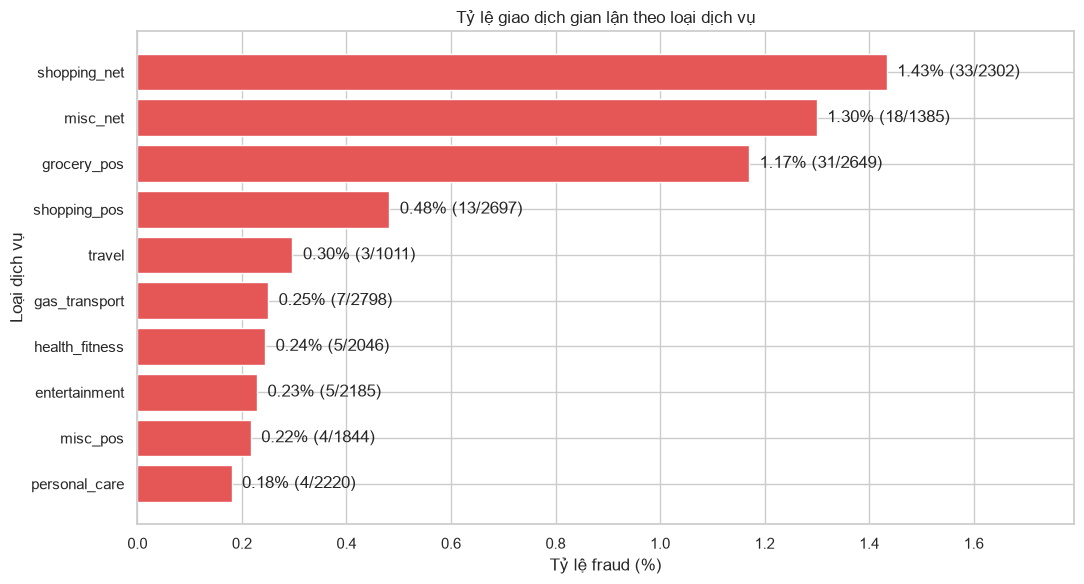

Lưu ý: số trong ngoặc là số fraud / tổng số giao dịch của nhóm.
Chi-square p-value: 1.28236e-23
Kết luận: category có liên hệ có ý nghĩa thống kê với fraud.


In [ ]:
# ========================= 3.2 FRAUD THEO LOẠI DỊCH VỤ =========================
print('MỤC TIÊU: xem loại dịch vụ nào có tỷ lệ fraud cao hơn.')

service_stats = (
    eda_df.groupby('category')[label_col]
    .agg(total_transactions='count', fraud_count='sum')
 )
service_stats['fraud_rate'] = (
    service_stats['fraud_count'] / service_stats['total_transactions']
 )
service_stats = service_stats[service_stats['total_transactions'] >= 10]
service_stats = service_stats.sort_values('fraud_rate', ascending=False)

service_plot = service_stats.head(10).sort_values('fraud_rate').reset_index()
service_plot['fraud_rate_percent'] = service_plot['fraud_rate'] * 100
plt.figure(figsize=(11, 6))
bars = plt.barh(
    service_plot['category'],
    service_plot['fraud_rate_percent'],
    color='#E45756'
 )
for bar, (_, row) in zip(bars, service_plot.iterrows()):
    plt.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{row['fraud_rate_percent']:.2f}% "
        f"({int(row['fraud_count'])}/{int(row['total_transactions'])})",
        va='center'
    )
plt.title('Tỷ lệ giao dịch gian lận theo loại dịch vụ')
plt.xlabel('Tỷ lệ fraud (%)')
plt.ylabel('Loại dịch vụ')
plt.xlim(0, max(service_plot['fraud_rate_percent']) * 1.25)
plt.tight_layout(); plt.show()

print('Lưu ý: số trong ngoặc là số fraud / tổng số giao dịch của nhóm.')

# Kiểm tra category có liên hệ với fraud hay chỉ là chênh lệch ngẫu nhiên.
contingency_table = pd.crosstab(eda_df['category'], eda_df[label_col])
chi2_stat, chi2_pvalue, chi2_dof, _ = chi2_contingency(contingency_table)
print(f'Chi-square p-value: {chi2_pvalue:.6g}')
if chi2_pvalue < 0.05:
    print('Kết luận: category có liên hệ có ý nghĩa thống kê với fraud.')
else:
    print('Kết luận: chưa đủ bằng chứng về liên hệ giữa category và fraud.')

### 3.3 Kiểm tra giá trị bất thường

**Outlier (giá trị bất thường)** là những giá trị chênh lệch rất lớn so với phần lớn dữ liệu.

Ví dụ:

- Số tiền giao dịch quá lớn.
- Khoảng cách giữa hai giao dịch quá xa.
- Một thẻ giao dịch quá nhiều lần trong một giờ.

Trong bài toán fraud, không nên xóa toàn bộ outlier vì chính các giá trị bất thường có thể chứa giao dịch gian lận.

Việc xử lý outlier chính thức sẽ được thực hiện sau khi chia Train/Test để tránh sử dụng thông tin từ Test.




MỤC TIÊU: kiểm tra giá trị bất thường


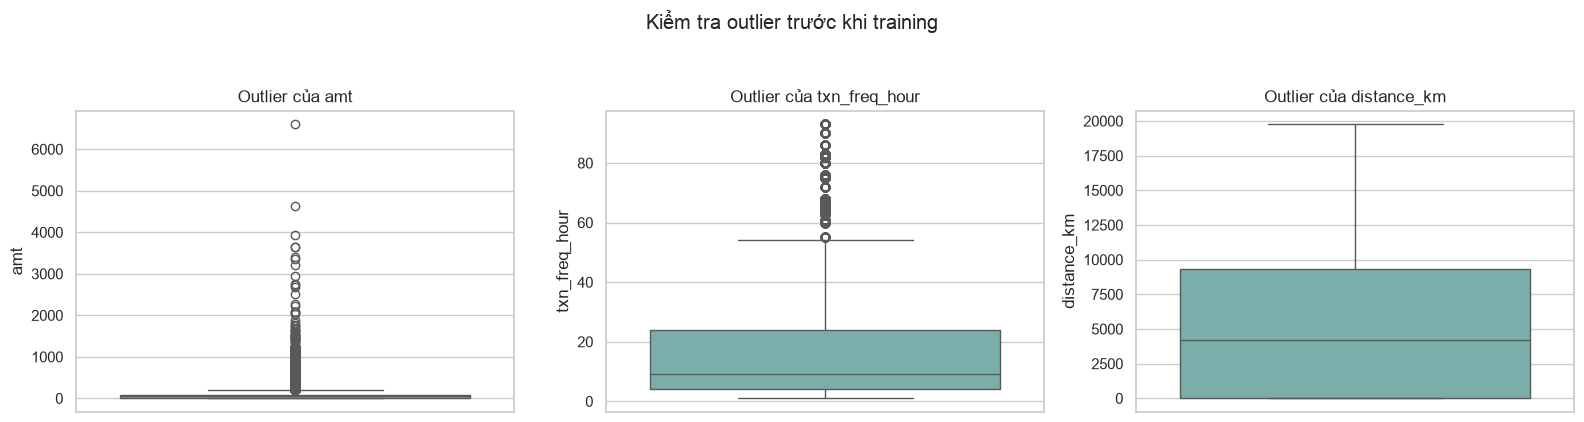

,Đặc trưng,Ngưỡng dưới,Ngưỡng trên,Tổng số dòng,Số outlier,Tỷ lệ outlier,Fraud trong outlier,Quyết định
0,amt,-100.00,192.16,30058,1521,5.06%,104,"Giữ dòng, clip trên train"
1,txn_freq_hour,-26.00,54.00,30058,1806,6.01%,10,"Giữ dòng, clip trên train"
2,distance_km,-13999.81,23333.02,30058,0,0.00%,0,"Giữ dòng, clip trên train"


Kết luận: không xóa outlier tại đây vì outlier có thể chính là fraud.
Việc clip thật sự sẽ làm sau khi chia train/test ở phần 5.

Tổng số feature được chọn: 14
Danh sách: ['amt', 'age', 'amt_vs_card_median', 'hour', 'txn_freq_hour', 'distance_km', 'category', 'amt_log', 'amt_zscore_card', 'is_night', 'speed_kmh', 'amt_per_km', 'txn_count_recent', 'amt_vs_card_avg']


In [ ]:
# ========================= 3.3 OUTLIER VÀ CHỌN FEATURE =========================
print('MỤC TIÊU: kiểm tra giá trị bất thường')

# Danh sách feature sẽ dùng cho model (đồng bộ với cell 19)
selected_training_features = [
    # Features gốc
    'amt', 'age', 'amt_vs_card_median', 'hour',
    'txn_freq_hour', 'distance_km', 'category',
    # Features bổ sung
    'amt_log', 'amt_zscore_card', 'is_night',
    'speed_kmh', 'amt_per_km',
    'txn_count_recent', 'amt_vs_card_avg',
]

# Boxplot giúp nhìn nhanh các giá trị nằm xa phần lớn dữ liệu.
outlier_features = ['amt', 'txn_freq_hour', 'distance_km']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, feature in zip(axes, outlier_features):
    sns.boxplot(y=eda_df[feature], color='#72B7B2', ax=axis)
    axis.set_title(f'Outlier của {feature}')
plt.suptitle('Kiểm tra outlier trước khi training', y=1.05)
plt.tight_layout()
plt.show()

# Thống kê outlier bằng quy tắc IQR.
outlier_rows = []
for feature in outlier_features:
    first_quartile, third_quartile = eda_df[feature].quantile([0.25, 0.75])
    interquartile_range = third_quartile - first_quartile
    lower_limit = first_quartile - 1.5 * interquartile_range
    upper_limit = third_quartile + 1.5 * interquartile_range
    outlier_mask = (
        (eda_df[feature] < lower_limit)
        | (eda_df[feature] > upper_limit)
    )
    outlier_rows.append({
        'Đặc trưng': feature,
        'Ngưỡng dưới': lower_limit,
        'Ngưỡng trên': upper_limit,
        'Tổng số dòng': len(eda_df),
        'Số outlier': int(outlier_mask.sum()),
        'Tỷ lệ outlier': outlier_mask.mean(),
        'Fraud trong outlier': int(eda_df.loc[outlier_mask, label_col].sum()),
        'Quyết định': 'Giữ dòng, clip trên train'
    })
outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary.style.format({
    'Ngưỡng dưới': '{:.2f}',
    'Ngưỡng trên': '{:.2f}',
    'Tỷ lệ outlier': '{:.2%}'
}))
print('Kết luận: không xóa outlier tại đây vì outlier có thể chính là fraud.')
print('Việc clip thật sự sẽ làm sau khi chia train/test ở phần 5.')
print(f'\nTổng số feature được chọn: {len(selected_training_features)}')
print(f'Danh sách: {selected_training_features}')

## 4. Chia Train/Test và tiền xử lý dữ liệu

Dữ liệu được chia thành:

- **Train – 80%:** dùng để huấn luyện mô hình (sau đó chia thêm Fit/Validation).
- **Test – 20%:** dùng để đánh giá cuối cùng.

### Tránh Data Leakage

**Data Leakage** xảy ra khi thông tin từ Test vô tình được dùng trong quá trình huấn luyện.

Để tránh tình trạng này:

- Toàn bộ đặc trưng (feature) được tính **SAU khi chia Train/Test**: hồ sơ thẻ (thống kê theo từng thẻ, gọi là card profile) chỉ được ước lượng trên Train, mỗi tập dữ liệu tự xây dựng đặc trưng từ dữ liệu thô của chính tập đó — không tính đặc trưng trên toàn bộ dữ liệu trước khi chia.
- Giới hạn xử lý giá trị bất thường (IQR) chỉ được tính từ **Train**.
- Fit và Validation được tách TRƯỚC khi chuẩn hóa (Bước 4); StandardScaler và TargetEncoder chỉ được **ước lượng trên Fit**, còn Validation được biến đổi riêng — mô hình không nhìn thấy nhãn của Validation qua TargetEncoder.
- **Test KHÔNG được biến đổi ở bước chuẩn bị dữ liệu** — chỉ biến đổi sau khi hoàn tất tinh chỉnh.

### Xử lý outlier bằng IQR

Các ký hiệu:

- `Q1`: mốc 25% của dữ liệu.
- `Q3`: mốc 75%.
- `IQR = Q3 - Q1`.

Giá trị quá lớn hoặc quá nhỏ sẽ được giới hạn lại bằng `clip`, thay vì xóa cả giao dịch.

### StandardScaler

Các feature số có thang đo khác nhau nên được chuẩn hóa.

Sau StandardScaler:

- Trung bình xấp xỉ `0`.
- Độ lệch chuẩn xấp xỉ `1`.

### TargetEncoder

Thay vì One-Hot Encoding (tăng chiều dữ liệu), sử dụng **TargetEncoder** để mã hóa `category` theo tương quan với biến `is_fraud`. Điều này giúp giữ nguyên 1 cột thay vì nhiều cột One-Hot.







In [ ]:
!pip install category_encoders -q
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SKPipeline
from category_encoders import TargetEncoder

In [ ]:
# Mở rộng tập đặc trưng để cải thiện mô hình
selected_training_features = [
    # Đặc trưng gốc
    'amt', 'age', 'amt_vs_card_median', 'hour',
    'txn_freq_hour', 'distance_km', 'category',
    # Đặc trưng bổ sung
    'amt_log', 'amt_zscore_card', 'is_night',
    'speed_kmh', 'amt_per_km',
    # Đặc trưng mới
    'txn_count_recent', 'amt_vs_card_avg',
]

# ============ SỬA DATA LEAKAGE ============#
#   1. Chia dữ liệu THÔ (raw) thành train/test TRƯỚC.
#   2. Fit "hồ sơ thẻ" (card profile) CHỈ trên tập train.
#   3. Build feature cho CẢ train lẫn test từ hồ sơ đó (test không ảnh hưởng train).
#   4. Feature theo chuỗi thời gian (distance_km, speed_kmh, txn_count_recent)
#      được tính riêng trong TỪNG tập, không trộn 2 tập với nhau.

# Các cột thô cần dùng (chưa qua bất kỳ feature engineering nào)
raw_feature_cols = ['cc_num', 'amt', 'lat', 'long', 'trans_date_trans_time',
                    'dob', 'category', 'trans_num', 'is_fraud']


def fit_card_profile(train_raw):
    """Fit hồ sơ thẻ CHỈ từ tập train (median/mean/std của amt, tần suất theo giờ)."""
    hour_col = train_raw['trans_date_trans_time'].dt.hour
    profile = {
        'amt_median': train_raw.groupby('cc_num')['amt'].median(),
        'amt_mean': train_raw.groupby('cc_num')['amt'].mean(),
        'amt_std': train_raw.groupby('cc_num')['amt'].std().fillna(0.0),
        'hour_freq': train_raw.assign(hour=hour_col).groupby(['cc_num', 'hour']).size(),
        'global_median': train_raw['amt'].median(),
        'global_mean': train_raw['amt'].mean(),
        'global_std': train_raw['amt'].std(),
    }
    return profile


def build_features(part_raw, card_profile):
    """Build 14 features cho MỘT tập, dùng hồ sơ thẻ fit từ TRAIN (không rò rỉ test)."""
    part = part_raw.copy()
    part = part.sort_values('trans_date_trans_time')  # sắp theo thời gian, giữ nguyên index
    part['hour'] = part['trans_date_trans_time'].dt.hour

    # Thống kê theo thẻ: map từ profile (fit trên train); thẻ lạ -> giá trị toàn cục train
    med = part['cc_num'].map(card_profile['amt_median']).fillna(card_profile['global_median'])
    mean = part['cc_num'].map(card_profile['amt_mean']).fillna(card_profile['global_mean'])
    std = part['cc_num'].map(card_profile['amt_std']).fillna(card_profile['global_std'])

    part['age'] = (part['trans_date_trans_time'].dt.year
                   - pd.to_datetime(part['dob'], errors='coerce').dt.year)
    part['amt_vs_card_median'] = part['amt'] - med
    part['txn_freq_hour'] = part[['cc_num', 'hour']].apply(
        lambda r: int(card_profile['hour_freq'].get((r['cc_num'], r['hour']), 0)), axis=1
    )
    part['amt_log'] = np.log1p(part['amt'])
    part['amt_zscore_card'] = (part['amt'] - mean) / std.clip(lower=0.01)
    part['is_night'] = part['hour'].apply(lambda h: 1 if h >= 22 or h < 5 else 0).astype(int)

    # Feature theo chuỗi thời gian — tính riêng trong tập này
    prev_lat = part.groupby('cc_num')['lat'].shift(1)
    prev_lon = part.groupby('cc_num')['long'].shift(1)
    part['distance_km'] = calculate_distance(
        part['lat'], part['long'], prev_lat, prev_lon
    ).fillna(0.0)

    time_diff_h = (part.groupby('cc_num')['trans_date_trans_time'].diff()
                   .dt.total_seconds().fillna(3600) / 3600)
    part['speed_kmh'] = part['distance_km'] / time_diff_h.clip(lower=0.01)
    part['amt_per_km'] = part['amt'] / part['distance_km'].clip(lower=0.01)
    part['txn_count_recent'] = part.groupby('cc_num')['trans_num'].cumcount() + 1
    part['amt_vs_card_avg'] = part['amt'] / mean.clip(lower=0.01)

    return part[selected_training_features]


print(f'Số lượng feature: {len(selected_training_features)}')
print(f'Danh sách: {selected_training_features}')

Số lượng feature: 14
Danh sách: ['amt', 'age', 'amt_vs_card_median', 'hour', 'txn_freq_hour', 'distance_km', 'category', 'amt_log', 'amt_zscore_card', 'is_night', 'speed_kmh', 'amt_per_km', 'txn_count_recent', 'amt_vs_card_avg']


In [ ]:
# ==================== BƯỚC 1: CHIA TÁCH DỮ LIỆU ĐỂ KIỂM CHỨNG (TRAIN-TEST SPLIT) ====================
# Chia dữ liệu THÔ trước, fit hồ sơ thẻ trên train, rồi mới build feature từng tập.
# Điều này đảm bảo feature KHÔNG rò rỉ dữ liệu test vào quá trình huấn luyện.

y_full = df['is_fraud'].astype(int)
df_raw_train, df_raw_test, y_train, y_test = train_test_split(
    df[raw_feature_cols], y_full,
    test_size=0.20, stratify=y_full, random_state=42
)

# Hồ sơ thẻ CHỈ fit từ train
card_profile = fit_card_profile(df_raw_train)

# Build feature riêng cho train và test (cùng hồ sơ, không trộn dữ liệu)
X_train_raw = build_features(df_raw_train, card_profile)
X_test_raw = build_features(df_raw_test, card_profile)

# Đồng bộ index: build_features sắp lại theo thời gian
y_train = y_train.loc[X_train_raw.index].reset_index(drop=True)
y_test = y_test.loc[X_test_raw.index].reset_index(drop=True)
X_train_raw = X_train_raw.reset_index(drop=True)
X_test_raw = X_test_raw.reset_index(drop=True)

# Kích thước tập train
X_train_raw.shape


(24046, 14)

In [ ]:
# ==================== BƯỚC 3: XỬ LÝ SỐ LIỆU ĐỘT BIẾN (OUTLIER CLIPPING) ====================
# Chỉ clip trên tập Train để tránh data leakage.
# Test sẽ được transform sau cùng khi đánh giá.

cat_features = X_train_raw.select_dtypes(include=['object', 'category', 'string']).columns
num_features = X_train_raw.select_dtypes(include=['number']).columns

X_train_clean = X_train_raw.copy()
iqr_bounds = {}
for col in num_features:
    q1, q3 = X_train_raw[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_bounds[col] = (lower, upper)
    X_train_clean[col] = X_train_clean[col].clip(lower, upper)

print(f'IQR clipping applied to {len(num_features)} numeric features on TRAIN only.')
print(f'Train shape: {X_train_clean.shape} | Test shape (untouched): {X_test_raw.shape}')

IQR clipping applied to 13 numeric features on TRAIN only.
Train shape: (24046, 14) | Test shape (untouched): (6012, 14)


In [ ]:
# ==================== BƯỚC 4: ĐỒNG BỘ THANG ĐO (STANDARD SCALING) ====================

# --- 1. Tách Fit / Validation TỪ DỮ LIỆU SẠCH (chưa encode) ---
y_train_array = np.asarray(y_train).ravel()
X_fit_clean, X_validation_clean, y_fit, y_validation = train_test_split(
    X_train_clean, y_train_array,
    test_size=0.20, stratify=y_train_array, random_state=42,
)

# --- 2. Fit preprocessor CHỈ trên Fit (Validation/Test không tham gia) ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', TargetEncoder(), cat_features)
    ],
    remainder='drop'
)

X_fit_encoded = preprocessor.fit_transform(X_fit_clean, y_fit)

# Lấy tên cột sau encoding
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
feature_names = list(num_features) + list(cat_feature_names)

if hasattr(X_fit_encoded, 'toarray'):
    X_fit_encoded = X_fit_encoded.toarray()

X_fit_encoded = pd.DataFrame(
    X_fit_encoded,
    columns=feature_names,
    index=X_fit_clean.index
)

# --- 3. Transform Validation bằng preprocessor đã fit trên Fit (không leak) ---
X_validation_encoded = preprocessor.transform(X_validation_clean)
if hasattr(X_validation_encoded, 'toarray'):
    X_validation_encoded = X_validation_encoded.toarray()

X_validation_encoded = pd.DataFrame(
    X_validation_encoded,
    columns=feature_names,
    index=X_validation_clean.index
)

# KHÔNG transform test ở đây — chỉ transform sau khi chọn model tốt nhất
X_test_encoded = None  # sẽ được gán sau

print('Thống kê Fit sau IQR clipping + StandardScaler:')
display(
    X_fit_encoded[num_features]
    .describe()
    .loc[['mean', 'std', 'min', 'max']]
    .round(2)
)

print(f'\nFit: {X_fit_encoded.shape}')
print(f'Validation: {X_validation_encoded.shape}')
print(f'Fit labels: {pd.Series(y_fit).value_counts().to_dict()}')
print('Test sẽ được transform sau khi hoàn tất tuning.')




Thống kê Fit sau IQR clipping + StandardScaler:


,amt,age,amt_vs_card_median,hour,txn_freq_hour,distance_km,amt_log,amt_zscore_card,is_night,speed_kmh,amt_per_km,txn_count_recent,amt_vs_card_avg
mean,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.06,-1.81,-2.28,-1.96,-0.95,-0.97,-2.21,-2.54,-0.60,-0.72,-0.63,-0.90,-1.07
max,2.54,2.69,2.44,1.46,2.43,2.67,3.11,2.30,1.68,2.05,1.85,2.27,2.56



Fit: (19236, 14)
Validation: (4810, 14)
Fit labels: {0: 19151, 1: 85}
Test sẽ được transform sau khi hoàn tất tuning.


In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Kiểm tra ý nghĩa thống kê của từng đặc trưng (trên tập Fit, sau khi chuẩn hóa)
X_fit_logit = sm.add_constant(X_fit_encoded)
logit_model = sm.Logit(y_fit, X_fit_logit).fit()
print(logit_model.summary())



Optimization terminated successfully.
         Current function value: 0.015370
         Iterations 13
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                19236
Model:                          Logit   Df Residuals:                    19221
Method:                           MLE   Df Model:                           14
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                  0.4582
Time:                        01:31:30   Log-Likelihood:                -295.65
converged:                       True   LL-Null:                       -545.67
Covariance Type:            nonrobust   LLR p-value:                 9.056e-98
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -8.7246      0.352    -24.765      0.000      -9.415      -8.034
amt 

=> Kết quả phân tích trên tập Fit

- Phép kiểm định này dùng mô hình hồi quy logistic (Logit) để xem từng đặc trưng có liên quan đến nhãn gian lận hay không. Đây là mô hình đơn giản dạng tuyến tính, khác với các mô hình chính của đồ án (dạng cây quyết định), nên kết quả chỉ dùng để tham khảo.
- Nhiều đặc trưng trùng lặp thông tin với nhau (hiện tượng đa cộng tuyến): VIF của `amt` ≈ 127, `amt_vs_card_median` ≈ 137, `amt_zscore_card` ≈ 12, `amt_vs_card_avg` ≈ 37. Khi các đặc trưng tương quan chéo, chỉ số ý nghĩa (p-value) của từng đặc trưng trở nên kém tin cậy: một đặc trưng có p-value lớn vẫn có thể chứa thông tin hữu ích được phản ánh qua các đặc trưng khác.
- Thử nghiệm thực tế với nhiều cách chia dữ liệu khác nhau cho thấy **giữ cả 14 đặc trưng cho PR-AUC cao hơn** so với bỏ bớt (giữ đủ 14 đặc trưng: PR-AUC ≈ 0.86; bỏ bớt các đặc trưng có p-value lớn: 0.83–0.84).
- Kết luận: **giữ nguyên 14 đặc trưng**. Không loại bỏ đặc trưng chỉ dựa trên p-value của Logit, vì việc bỏ bớt làm giảm kết quả thực tế và dễ khiến mô hình quá khớp (overfit) với một tiêu chí tuyến tính không phản ánh đúng các mô hình chính.



,is_fraud
is_fraud,1.000000
amt,0.128190
amt_vs_card_median,0.122485
amt_vs_card_avg,0.119596
amt_log,0.118076
amt_zscore_card,0.108560
is_night,0.090544
category,0.071760
txn_count_recent,0.036631
amt_per_km,0.029384


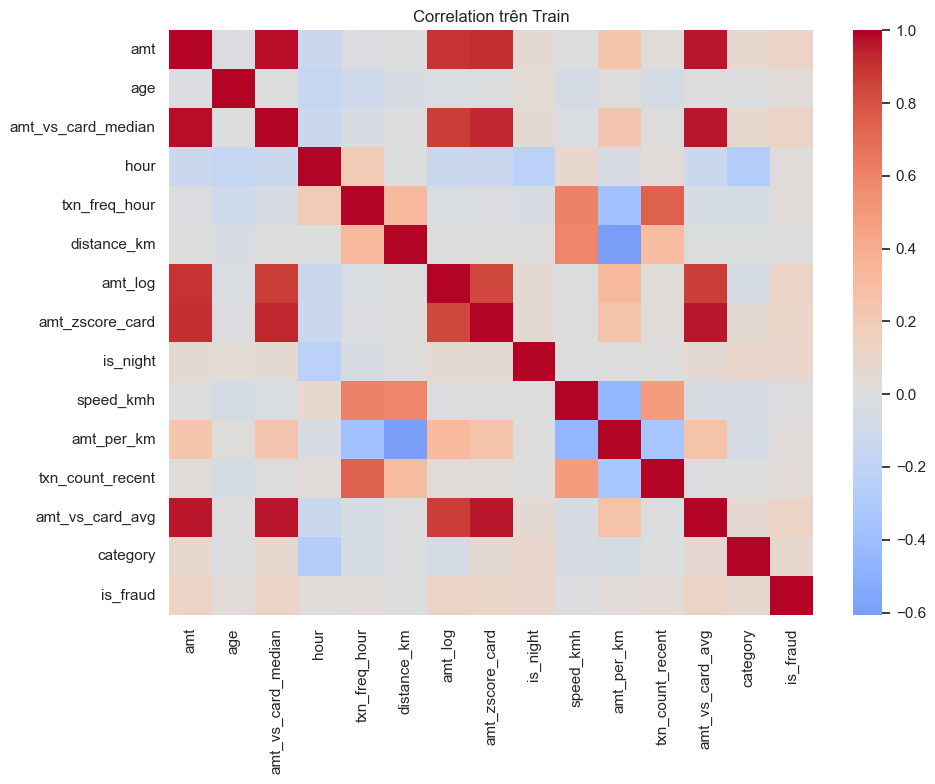

In [ ]:
# corr_columns = num_features + ["is_fraud"]
df2 = pd.concat(
    [
        X_fit_encoded.reset_index(drop=True),
        pd.Series(y_fit, name="is_fraud")
    ],
    axis=1
)
train_corr = df2.corr(numeric_only=True)
display(train_corr[['is_fraud']].sort_values('is_fraud', ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(train_corr, cmap="coolwarm", center=0, square=False)
plt.title("Correlation trên Train")
plt.tight_layout()
plt.show()

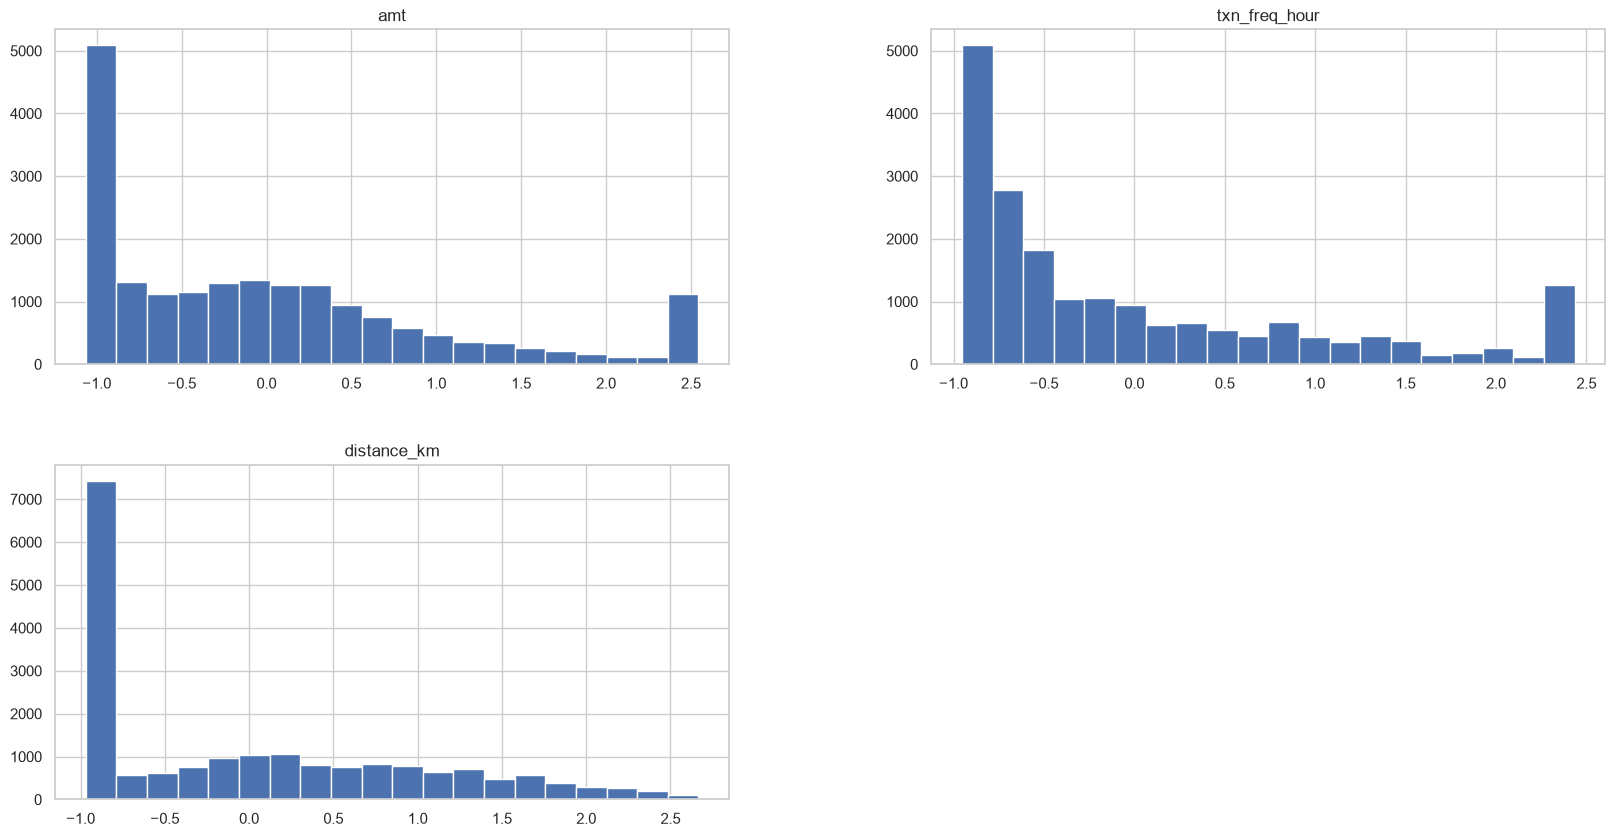

In [ ]:
# Phân bố dữ liệu sau khi chuẩn hóa (tập Fit)
X_fit_encoded[['amt', 'txn_freq_hour', 'distance_km']].hist(bins = 20, figsize =(20, 10))
plt.show()



### 6.1. Chuẩn bị các chỉ số đánh giá mô hình

Trước khi huấn luyện và so sánh các mô hình, cần chuẩn bị các chỉ số dùng để đo chất lượng dự đoán.

Các chỉ số chính gồm:

- **Precision:** trong các giao dịch bị cảnh báo là fraud, có bao nhiêu giao dịch thật sự là fraud.
- **Recall:** trong các giao dịch gian lận thật sự, mô hình phát hiện được bao nhiêu.
- **F1-Score:** cân bằng giữa Precision và Recall.
- **F2-Score:** tương tự F1 nhưng ưu tiên Recall nhiều hơn.
- **ROC-AUC:** đo khả năng phân biệt giao dịch bình thường và gian lận.
- **PR-AUC:** đánh giá mối quan hệ giữa Precision và Recall, phù hợp với dữ liệu mất cân bằng.

Ngoài ra, biến `evaluation_results` được tạo để lưu kết quả của từng mô hình. Các kết quả này sẽ được sử dụng ở phần sau để lập bảng so sánh các mô hình.



In [ ]:
# NẠP THƯ VIỆN & KHỞI TẠO BIẾN LƯU KẾT QUẢ
# Mục tiêu: Chuẩn bị công cụ đo lường và danh sách để lập bảng so sánh các mô hình.

from sklearn.metrics import (
    precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, classification_report
)

# Danh sách chung lưu trữ điểm số của tất cả các mô hình
evaluation_results = []
print("- Đã nạp thư viện đánh giá và khởi tạo biến lưu kết quả.")

- Đã nạp thư viện đánh giá và khởi tạo biến lưu kết quả.


In [ ]:
def evaluate_model(model_name, y_true, y_pred, y_probability):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_probability)
    pr_auc = average_precision_score(y_true, y_probability)
    evaluation_results.append(
        {
            "Mô hình": model_name,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "F2-Score": f2,
            "ROC-AUC": roc_auc,
            "PR-AUC": pr_auc,
        }
    )
    # In báo cáo chi tiết.
    print(f"\nKẾT QUẢ MÔ HÌNH: {model_name.upper()}")
    print("=" * 60)
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    print(f"- Precision : {precision:.4f}")
    print(f"- Recall    : {recall:.4f}")
    print(f"- F1-Score  : {f1:.4f}")
    print(f"- F2-Score  : {f2:.4f}")
    print(f"- ROC-AUC   : {roc_auc:.4f}")
    print(f"- PR-AUC    : {pr_auc:.4f}")

### 6.2 Huấn luyện mô hình và chọn Threshold

Ở bước này, dữ liệu được tổ chức thành ba phần:

- **Fit:** dùng để huấn luyện mô hình.
- **Validation:** dùng để chọn ngưỡng quyết định (Threshold) phù hợp.
- **Test:** chỉ dùng để đánh giá kết quả cuối cùng.

Trong bài toán phát hiện gian lận, ngưỡng thấp giúp phát hiện được nhiều giao dịch gian lận hơn nhưng cũng có thể làm tăng số cảnh báo nhầm.

Vì vậy, Validation được dùng để thử nhiều ngưỡng khác nhau và chọn ngưỡng có **F2-Score cao nhất**.

F2-Score được ưu tiên vì nó coi trọng **Recall** nhiều hơn Precision, phù hợp với mục tiêu hạn chế bỏ sót giao dịch gian lận.

Sau khi chọn được ngưỡng, mô hình đã được huấn luyện trên tập Fit sẽ được đánh giá một lần cuối trên Test.

Cách làm này giữ cho Test luôn độc lập và tránh việc chọn ngưỡng dựa trực tiếp trên dữ liệu Test.





Kích thước dữ liệu:
- Fit       : 19,236
- Validation: 4,810
- Test      : 6,012

Tỷ lệ fraud:
- Fit       : 0.4419%
- Validation: 0.4366%
- Test      : 0.4491%

Neg/Pos ratio: 225.31

################################################################################
# 7. RANDOM FOREST
################################################################################
Fitting 5 folds for each of 80 candidates, totalling 400 fits



Best RF CV PR-AUC: 0.7555
Best RF params: {'class_weight': {0: 1, 1: 40}, 'criterion': 'entropy', 'max_depth': 15, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 1012}



Random Forest | Tuned class weight
Threshold   : 0.2498
Precision   : 0.7500
Recall      : 0.8571
F1          : 0.8000
F2          : 0.8333
ROC-AUC     : 0.9949
PR-AUC      : 0.8350


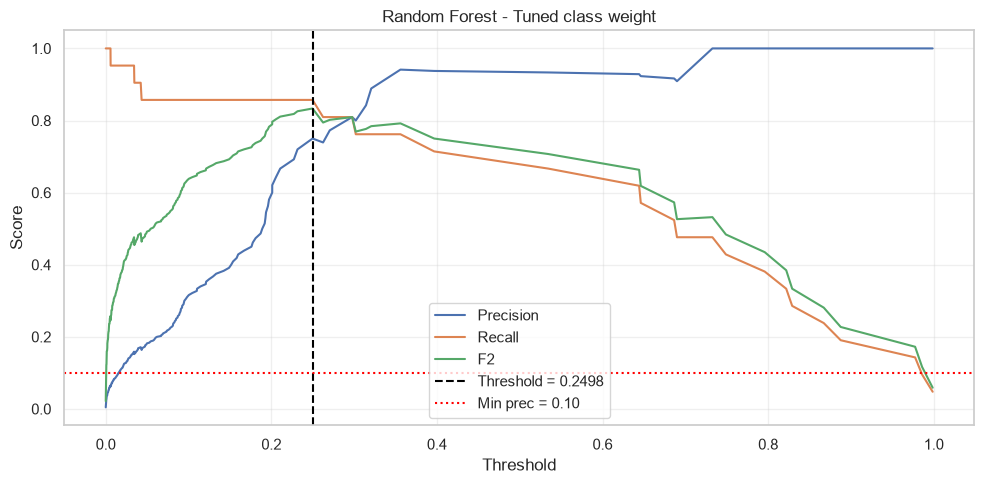

RF tuning time: 511.6s

################################################################################
# 8. XGBOOST -- SCALE POS WEIGHT
################################################################################
Fitting 5 folds for each of 80 candidates, totalling 400 fits



Best XGB-Weighted CV PR-AUC: 0.7973
Best params: {'colsample_bytree': np.float64(0.8686326600082206), 'gamma': np.float64(0.041168988591604894), 'learning_rate': np.float64(0.13540804321249839), 'max_depth': 5, 'min_child_weight': 6, 'n_estimators': 685, 'reg_alpha': np.float64(0.0009201520650562242), 'reg_lambda': np.float64(0.1774939416098251), 'scale_pos_weight': np.float64(56.326470588235296), 'subsample': np.float64(0.8252439222197265)}

XGBoost | Scale Pos Weight
Threshold   : 0.2545
Precision   : 0.5758
Recall      : 0.9048
F1          : 0.7037
F2          : 0.8120
ROC-AUC     : 0.9959
PR-AUC      : 0.8349


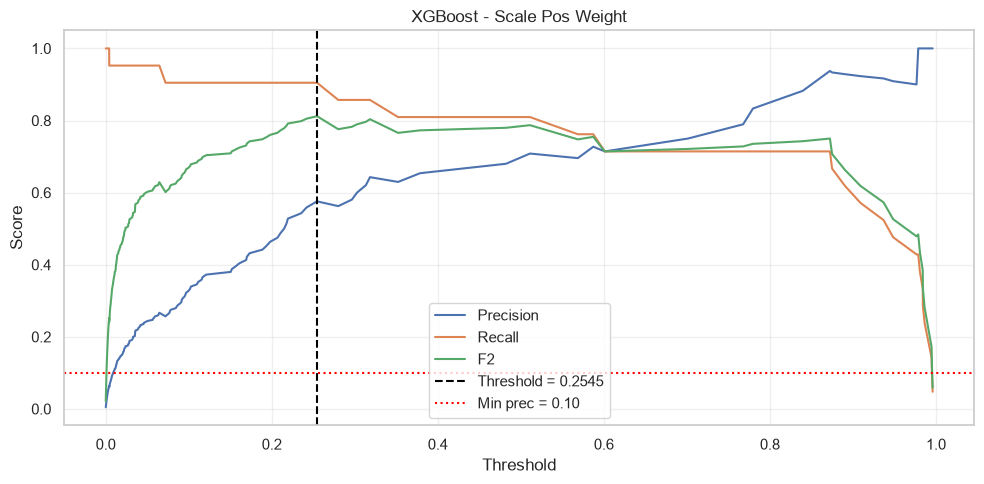

XGB-Weighted tuning time: 15.4s

################################################################################
# 9. XGBOOST -- LIGHT SMOTE
################################################################################
Fitting 5 folds for each of 80 candidates, totalling 400 fits



Best XGB-SMOTE CV PR-AUC: 0.7642
Best params: {'model__colsample_bytree': np.float64(0.9447402433658988), 'model__gamma': np.float64(0.7848902148452708), 'model__learning_rate': np.float64(0.08038710581046055), 'model__max_depth': 8, 'model__min_child_weight': 8, 'model__n_estimators': 1099, 'model__reg_alpha': np.float64(0.028358249698737882), 'model__reg_lambda': np.float64(0.4009623796830938), 'model__subsample': np.float64(0.8864242210793131), 'sampler__k_neighbors': 5, 'sampler__sampling_strategy': 0.02}

XGBoost | Light SMOTE
Threshold   : 0.1655
Precision   : 0.5862
Recall      : 0.8095
F1          : 0.6800
F2          : 0.7522
ROC-AUC     : 0.9918
PR-AUC      : 0.7401


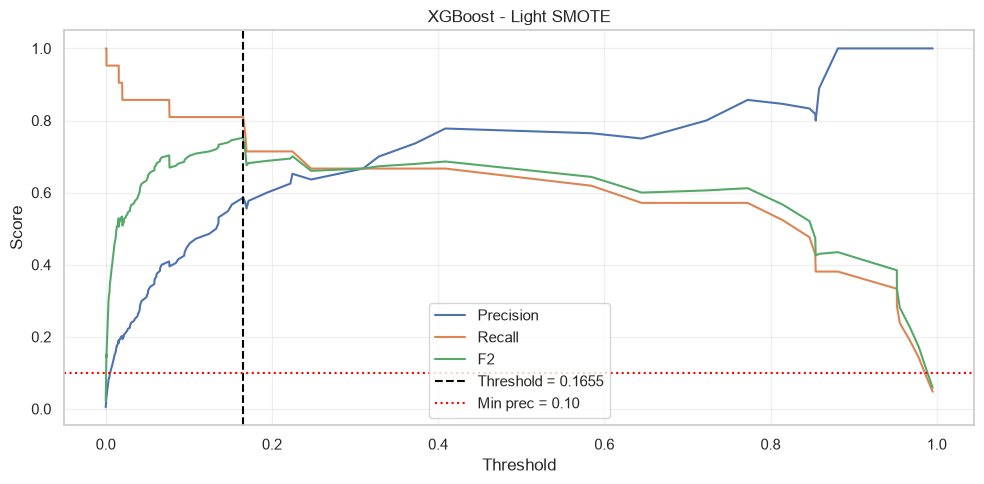

XGB-SMOTE tuning time: 34.9s

################################################################################
# 10. LIGHTGBM -- SCALE POS WEIGHT
################################################################################
Fitting 5 folds for each of 60 candidates, totalling 300 fits



Best LightGBM CV PR-AUC: 0.8525
Best params: {'colsample_bytree': np.float64(0.8219878206750177), 'learning_rate': np.float64(0.031360339417413396), 'max_depth': 6, 'min_child_samples': 17, 'n_estimators': 1483, 'num_leaves': 21, 'reg_alpha': np.float64(0.0028103296447636083), 'reg_lambda': np.float64(0.13136433318408583), 'scale_pos_weight': np.float64(15.010192615451048), 'subsample': np.float64(0.830959321660207)}

LightGBM | Scale Pos Weight
Threshold   : 0.0634
Precision   : 0.7727
Recall      : 0.8095
F1          : 0.7907
F2          : 0.8019
ROC-AUC     : 0.9928
PR-AUC      : 0.8324


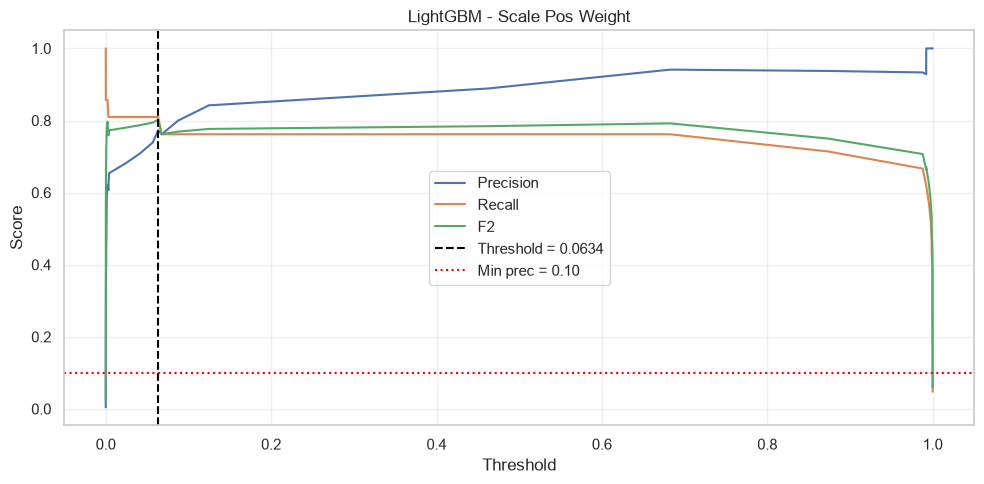

LightGBM tuning time: 231.8s

################################################################################
# 11. CATBOOST -- AUTO CLASS WEIGHTS
################################################################################
Fitting 5 folds for each of 40 candidates, totalling 200 fits



Best CatBoost CV PR-AUC: 0.7883
Best params: {'bagging_temperature': np.float64(0.9429097039125192), 'border_count': 149, 'depth': 4, 'iterations': 991, 'l2_leaf_reg': np.float64(0.5336533066379611), 'learning_rate': np.float64(0.1362730492074234), 'min_data_in_leaf': 12, 'random_strength': np.float64(0.5035645916507283)}

CatBoost | Auto class weights
Threshold   : 0.8407
Precision   : 0.4474
Recall      : 0.8095
F1          : 0.5763
F2          : 0.6967
ROC-AUC     : 0.9911
PR-AUC      : 0.6036


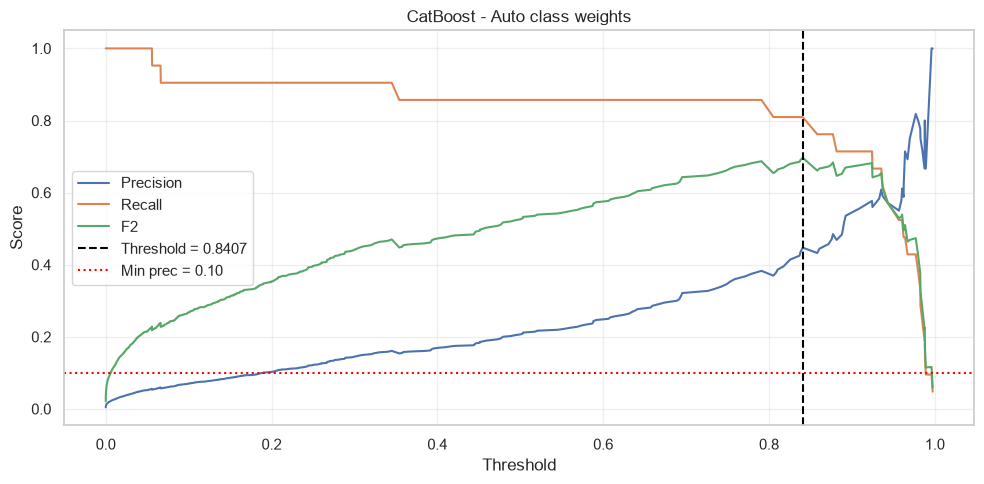

CatBoost tuning time: 73.6s

KẾT QUẢ TUNING TRÊN VALIDATION -- tất cả model


,Model,Imbalance method,Threshold,Precision,Recall,F1,F2,ROC-AUC,PR-AUC,Tuning time (s)
0,Random Forest,Tuned class weight,0.2498,0.7500,0.8571,0.8000,0.8333,0.9949,0.8350,511.56
1,XGBoost,Scale Pos Weight,0.2545,0.5758,0.9048,0.7037,0.8120,0.9959,0.8349,15.45
2,LightGBM,Scale Pos Weight,0.0634,0.7727,0.8095,0.7907,0.8019,0.9928,0.8324,231.85
3,XGBoost,Light SMOTE,0.1655,0.5862,0.8095,0.6800,0.7522,0.9918,0.7401,34.94
4,CatBoost,Auto class weights,0.8407,0.4474,0.8095,0.5763,0.6967,0.9911,0.6036,73.58



################################################################################
# 13. STACKING ENSEMBLE -- TOP 3 + META-LEARNER
################################################################################
3 model tốt nhất cho stacking:
  - Random Forest (Tuned class weight) | F2=0.8333, PR-AUC=0.8350
  - XGBoost (Scale Pos Weight) | F2=0.8120, PR-AUC=0.8349
  - LightGBM (Scale Pos Weight) | F2=0.8019, PR-AUC=0.8324



Stacking | Top-3 + LogReg Meta
Threshold   : 0.9827
Precision   : 0.7826
Recall      : 0.8571
F1          : 0.8182
F2          : 0.8411
ROC-AUC     : 0.9950
PR-AUC      : 0.8476


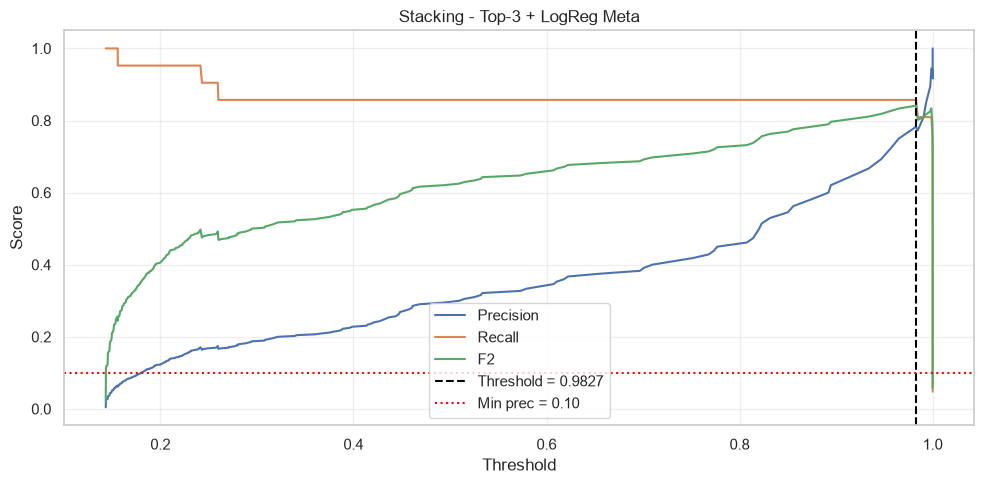

Stacking training time: 16.1s

KẾT QUẢ TUNING TRÊN VALIDATION -- HOÀN THÀNH


,Model,Imbalance method,Threshold,Precision,Recall,F1,F2,ROC-AUC,PR-AUC,Tuning time (s)
0,Stacking,Top-3 + LogReg Meta,0.9827,0.7826,0.8571,0.8182,0.8411,0.9950,0.8476,16.11
1,Random Forest,Tuned class weight,0.2498,0.7500,0.8571,0.8000,0.8333,0.9949,0.8350,511.56
2,XGBoost,Scale Pos Weight,0.2545,0.5758,0.9048,0.7037,0.8120,0.9959,0.8349,15.45
3,LightGBM,Scale Pos Weight,0.0634,0.7727,0.8095,0.7907,0.8019,0.9928,0.8324,231.85
4,XGBoost,Light SMOTE,0.1655,0.5862,0.8095,0.6800,0.7522,0.9918,0.7401,34.94
5,CatBoost,Auto class weights,0.8407,0.4474,0.8095,0.5763,0.6967,0.9911,0.6036,73.58



################################################################################
# 14. CALIBRATION ANALYSIS
################################################################################


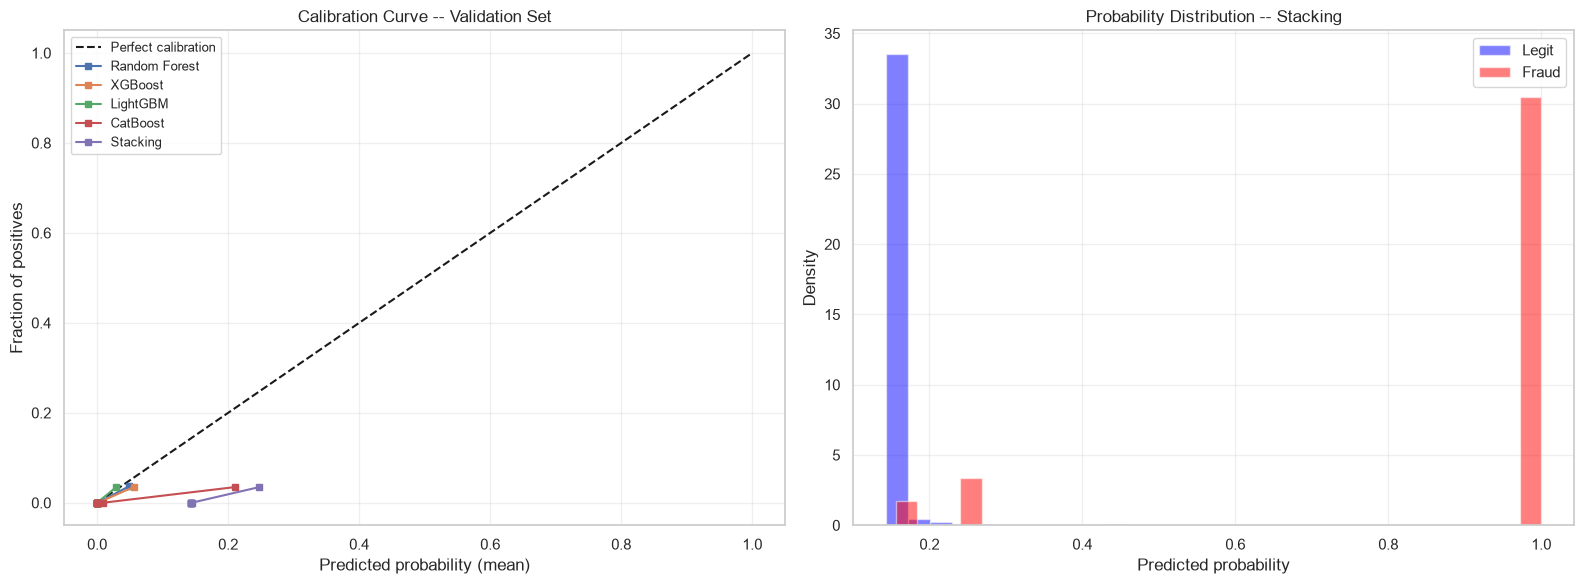

Calibration curve cho biết xác suất dự đoán có tin cậy không.
Nếu đường cong gần với đường chéo thì mức độ tin cậy (calibration) tốt.
Phân bố xác suất cho thấy model có phân biệt được fraud vs legit hay không.

TRANSFORM TEST SET
Test encoded shape: (6012, 14)
Test labels: {0: 5985, 1: 27}


In [ ]:
# =============================================================================
# TUNING PHÂN LOẠI GIAN LẬN -- CẢI TIẾN v2
#
# Các mô hình:
#   1. Random Forest -- tune class_weight
#   2. XGBoost -- scale_pos_weight
#   3. XGBoost -- Light SMOTE
#   4. LightGBM -- scale_pos_weight
#   5. CatBoost -- auto class weights
#   6. Stacking Ensemble -- meta-learner LogisticRegression (MOI)
#
# Cải tiến v2:
#   - Sửa lỗi CatBoost eval_metric
#   - Thêm 2 đặc trưng mới (txn_count_recent, amt_vs_card_avg)
#   - Stacking thay Soft Voting (meta-learner học trọng số tối ưu)
#   - Cross-validated threshold selection
#   - Probability calibration analysis
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint, uniform, loguniform

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV,
)
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


# =============================================================================
# 1. CAU HINH
# =============================================================================

RANDOM_STATE = 42
MIN_PRECISION = 0.10
N_ITER_RF = 80
N_ITER_XGB = 80
N_ITER_LGBM = 60
N_ITER_CAT = 40


# =============================================================================
# 2. CHUAN HOA Y
# =============================================================================

y_train_array = np.asarray(y_train).ravel()
y_test_array = np.asarray(y_test).ravel()


# =============================================================================
# 3. TACH FIT VA VALIDATION (đã tách ở Bước 4, trước khi fit preprocessor)
# =============================================================================

# Fit/Validation đã được tách từ dữ liệu sạch ở cell 22 và preprocessor chỉ fit
# trên Fit → không còn target leak qua TargetEncoder.
X_fit = X_fit_encoded
X_validation = X_validation_encoded
y_fit = np.asarray(y_fit).ravel()
y_validation = np.asarray(y_validation).ravel()

print('Kích thước dữ liệu:')
print(f'- Fit       : {len(y_fit):,}')
print(f'- Validation: {len(y_validation):,}')
print(f'- Test      : {len(y_test_array):,}')
print('\nTỷ lệ fraud:')
print(f'- Fit       : {np.mean(y_fit):.4%}')
print(f'- Validation: {np.mean(y_validation):.4%}')
print(f'- Test      : {np.mean(y_test_array):.4%}')


# =============================================================================
# 4. TÍNH TỶ LỆ MẤT CÂN BẰNG
# =============================================================================

negative_count = np.sum(y_fit == 0)
positive_count = np.sum(y_fit == 1)
imbalance_ratio = negative_count / positive_count

print(f'\nNeg/Pos ratio: {imbalance_ratio:.2f}')

n_splits = min(5, int(positive_count))
if n_splits < 3:
    raise ValueError('Tập Fit có quá ít fraud để thực hiện cross-validation.')

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)


# =============================================================================
# 5. HÀM CHỌN THRESHOLD -- Cross-validated
# =============================================================================

def find_best_threshold(y_true, probabilities, beta=2, min_precision=0.10):
    """Chọn threshold tối ưu dựa trên F2 score."""
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    precision = precision[:-1]
    recall = recall[:-1]
    beta_sq = beta ** 2
    fbeta = (1 + beta_sq) * precision * recall / (beta_sq * precision + recall + 1e-15)

    df = pd.DataFrame({
        'Threshold': thresholds, 'Precision': precision,
        'Recall': recall, 'F2': fbeta,
    })
    df['F1'] = 2 * df['Precision'] * df['Recall'] / (df['Precision'] + df['Recall'] + 1e-15)

    valid = df[df['Precision'] >= min_precision].copy()
    if valid.empty:
        print(f'Cảnh báo: không có threshold đạt Precision >= {min_precision:.2f}.')
        best_idx = df['F2'].idxmax()
    else:
        best_idx = valid.sort_values(by=['F2', 'Recall', 'Precision'], ascending=False).index[0]

    row = df.loc[best_idx]
    return float(row['Threshold']), float(row['F2']), df


def cv_threshold_selection(model, X_tr, y_tr, cv, beta=2, min_precision=0.10):
    """Chọn threshold bằng cross-validation để ổn định hơn."""
    thresholds_per_fold = []
    for train_idx, val_idx in cv.split(X_tr, y_tr):
        X_t, X_v = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
        y_t, y_v = y_tr[train_idx], y_tr[val_idx]

        m = clone(model)
        m.fit(X_t, y_t)
        probs = m.predict_proba(X_v)[:, 1]
        th, _, _ = find_best_threshold(y_v, probs, beta=beta, min_precision=min_precision)
        thresholds_per_fold.append(th)

    median_threshold = float(np.median(thresholds_per_fold))
    print(f'  Threshold qua {len(thresholds_per_fold)} folds: {[f"{t:.4f}" for t in thresholds_per_fold]}')
    print(f'  Median threshold: {median_threshold:.4f}')
    return median_threshold


# =============================================================================
# 6. HÀM ĐÁNH GIÁ TRÊN VALIDATION
# =============================================================================

def evaluate_validation(fitted_model, model_name, imbalance_method, threshold=None):
    probs = fitted_model.predict_proba(X_validation)[:, 1]
    if threshold is None:
        threshold, f2, tdf = find_best_threshold(y_validation, probs, beta=2, min_precision=MIN_PRECISION)
    else:
        _, f2, tdf = find_best_threshold(y_validation, probs, beta=2, min_precision=MIN_PRECISION)
    pred = (probs >= threshold).astype(int)

    result = {
        'Model': model_name, 'Imbalance method': imbalance_method,
        'Threshold': threshold,
        'Precision': precision_score(y_validation, pred, zero_division=0),
        'Recall': recall_score(y_validation, pred, zero_division=0),
        'F1': f1_score(y_validation, pred, zero_division=0),
        'F2': f2,
        'ROC-AUC': roc_auc_score(y_validation, probs),
        'PR-AUC': average_precision_score(y_validation, probs),
    }

    print('\n' + '=' * 80)
    print(f'{model_name} | {imbalance_method}')
    print('=' * 80)
    for k, v in result.items():
        if k not in ['Model', 'Imbalance method']:
            print(f'{k:<12}: {v:.4f}')

    plt.figure(figsize=(10, 5))
    plt.plot(tdf['Threshold'], tdf['Precision'], label='Precision')
    plt.plot(tdf['Threshold'], tdf['Recall'], label='Recall')
    plt.plot(tdf['Threshold'], tdf['F2'], label='F2')
    plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold = {threshold:.4f}')
    plt.axhline(MIN_PRECISION, color='red', linestyle=':', label=f'Min prec = {MIN_PRECISION:.2f}')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(f'{model_name} - {imbalance_method}')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return result


# =============================================================================
# 7. TUNE RANDOM FOREST
# =============================================================================

print('\n' + '#' * 80)
print('# 7. RANDOM FOREST')
print('#' * 80)

rf_model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

rf_parameter_space = {
    'n_estimators': randint(400, 1501),
    'max_depth': [None, 10, 15, 20, 25, 30, 40, 50],
    'min_samples_split': randint(2, 21),
    'min_samples_leaf': randint(1, 11),
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'class_weight': [
        'balanced', 'balanced_subsample',
        {0: 1, 1: 20}, {0: 1, 1: 40}, {0: 1, 1: 60},
        {0: 1, 1: 100}, {0: 1, 1: 150},
        {0: 1, 1: imbalance_ratio},
    ],
}

rf_search = RandomizedSearchCV(
    estimator=rf_model, param_distributions=rf_parameter_space,
    n_iter=N_ITER_RF, scoring='average_precision',
    cv=cv, refit=True, random_state=RANDOM_STATE,
    n_jobs=-1, verbose=1, return_train_score=True,
)

rf_start = time.perf_counter()
rf_search.fit(X_fit, y_fit)
rf_time = time.perf_counter() - rf_start

print(f'\nBest RF CV PR-AUC: {rf_search.best_score_:.4f}')
print(f'Best RF params: {rf_search.best_params_}')

rf_val = evaluate_validation(rf_search.best_estimator_, 'Random Forest', 'Tuned class weight')
rf_val['Tuning time (s)'] = round(rf_time, 2)
print(f'RF tuning time: {rf_time:.1f}s')


# =============================================================================
# 8. TUNE XGBOOST -- SCALE POS WEIGHT
# =============================================================================

print('\n' + '#' * 80)
print('# 8. XGBOOST -- SCALE POS WEIGHT')
print('#' * 80)

xgb_weighted = XGBClassifier(
    objective='binary:logistic', eval_metric='aucpr',
    tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1,
    early_stopping_rounds=30,
)

xgb_weighted_params = {
    'n_estimators': randint(300, 1501),
    'max_depth': randint(2, 10),
    'learning_rate': loguniform(0.005, 0.15),
    'min_child_weight': randint(1, 20),
    'gamma': uniform(0, 2.0),
    'subsample': uniform(0.55, 0.45),
    'colsample_bytree': uniform(0.55, 0.45),
    'reg_alpha': loguniform(1e-4, 20),
    'reg_lambda': loguniform(0.05, 50),
    'scale_pos_weight': [
        1, np.sqrt(imbalance_ratio),
        imbalance_ratio * 0.10, imbalance_ratio * 0.25,
        imbalance_ratio * 0.50, imbalance_ratio * 0.75,
        imbalance_ratio,
    ],
}

xgb_w_search = RandomizedSearchCV(
    estimator=xgb_weighted, param_distributions=xgb_weighted_params,
    n_iter=N_ITER_XGB, scoring='average_precision',
    cv=cv, refit=True, random_state=RANDOM_STATE,
    n_jobs=-1, verbose=1, return_train_score=True,
)

xgb_w_start = time.perf_counter()
xgb_w_search.fit(X_fit, y_fit, eval_set=[(X_validation, y_validation)], verbose=0)
xgb_w_time = time.perf_counter() - xgb_w_start

print(f'\nBest XGB-Weighted CV PR-AUC: {xgb_w_search.best_score_:.4f}')
print(f'Best params: {xgb_w_search.best_params_}')

xgb_w_val = evaluate_validation(xgb_w_search.best_estimator_, 'XGBoost', 'Scale Pos Weight')
xgb_w_val['Tuning time (s)'] = round(xgb_w_time, 2)
print(f'XGB-Weighted tuning time: {xgb_w_time:.1f}s')


# =============================================================================
# 9. TUNE XGBOOST -- LIGHT SMOTE
# =============================================================================

print('\n' + '#' * 80)
print('# 9. XGBOOST -- LIGHT SMOTE')
print('#' * 80)

xgb_smote_pipe = Pipeline(steps=[
    ('sampler', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ('model', XGBClassifier(
        objective='binary:logistic', eval_metric='aucpr',
        tree_method='hist', scale_pos_weight=1,
        random_state=RANDOM_STATE, n_jobs=-1,
    )),
])

xgb_smote_params = {
    'sampler__sampling_strategy': [0.02, 0.03, 0.05],
    'sampler__k_neighbors': [2, 3, 5],
    'model__n_estimators': randint(300, 1501),
    'model__max_depth': randint(2, 10),
    'model__learning_rate': loguniform(0.005, 0.15),
    'model__min_child_weight': randint(1, 20),
    'model__gamma': uniform(0, 2.0),
    'model__subsample': uniform(0.55, 0.45),
    'model__colsample_bytree': uniform(0.55, 0.45),
    'model__reg_alpha': loguniform(1e-4, 20),
    'model__reg_lambda': loguniform(0.05, 50),
}

xgb_s_search = RandomizedSearchCV(
    estimator=xgb_smote_pipe, param_distributions=xgb_smote_params,
    n_iter=N_ITER_XGB, scoring='average_precision',
    cv=cv, refit=True, random_state=RANDOM_STATE,
    n_jobs=-1, verbose=1, return_train_score=True,
)

xgb_s_start = time.perf_counter()
xgb_s_search.fit(X_fit, y_fit)
xgb_s_time = time.perf_counter() - xgb_s_start

print(f'\nBest XGB-SMOTE CV PR-AUC: {xgb_s_search.best_score_:.4f}')
print(f'Best params: {xgb_s_search.best_params_}')

xgb_s_val = evaluate_validation(xgb_s_search.best_estimator_, 'XGBoost', 'Light SMOTE')
xgb_s_val['Tuning time (s)'] = round(xgb_s_time, 2)
print(f'XGB-SMOTE tuning time: {xgb_s_time:.1f}s')


# =============================================================================
# 10. TUNE LIGHTGBM -- SCALE POS WEIGHT
# =============================================================================

print('\n' + '#' * 80)
print('# 10. LIGHTGBM -- SCALE POS WEIGHT')
print('#' * 80)

lgbm_model = LGBMClassifier(
    objective='binary', metric='average_precision',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    importance_type='gain',
)

lgbm_params = {
    'n_estimators': randint(300, 1501),
    'max_depth': randint(3, 12),
    'learning_rate': loguniform(0.005, 0.15),
    'num_leaves': randint(15, 64),
    'min_child_samples': randint(5, 50),
    'subsample': uniform(0.55, 0.45),
    'colsample_bytree': uniform(0.55, 0.45),
    'reg_alpha': loguniform(1e-4, 10),
    'reg_lambda': loguniform(0.05, 20),
    'scale_pos_weight': [
        1, np.sqrt(imbalance_ratio),
        imbalance_ratio * 0.25, imbalance_ratio * 0.50,
        imbalance_ratio * 0.75, imbalance_ratio,
    ],
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_model, param_distributions=lgbm_params,
    n_iter=N_ITER_LGBM, scoring='average_precision',
    cv=cv, refit=True, random_state=RANDOM_STATE,
    n_jobs=-1, verbose=1, return_train_score=True,
)

lgbm_start = time.perf_counter()
lgbm_search.fit(X_fit, y_fit, eval_set=[(X_validation, y_validation)])
lgbm_time = time.perf_counter() - lgbm_start

print(f'\nBest LightGBM CV PR-AUC: {lgbm_search.best_score_:.4f}')
print(f'Best params: {lgbm_search.best_params_}')

lgbm_val = evaluate_validation(lgbm_search.best_estimator_, 'LightGBM', 'Scale Pos Weight')
lgbm_val['Tuning time (s)'] = round(lgbm_time, 2)
print(f'LightGBM tuning time: {lgbm_time:.1f}s')


# =============================================================================
# 11. TUNE CATBOOST -- AUTO CLASS WEIGHTS (da sua eval_metric)
# =============================================================================

print('\n' + '#' * 80)
print('# 11. CATBOOST -- AUTO CLASS WEIGHTS')
print('#' * 80)

cat_model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=RANDOM_STATE, verbose=0,
    auto_class_weights='Balanced',
    early_stopping_rounds=30,
)

cat_params = {
    'iterations': randint(300, 1201),
    'depth': randint(4, 10),
    'learning_rate': loguniform(0.005, 0.15),
    'l2_leaf_reg': loguniform(0.1, 10),
    'bagging_temperature': uniform(0, 1),
    'random_strength': uniform(0, 2),
    'border_count': randint(32, 255),
    'min_data_in_leaf': randint(1, 20),
}

cat_search = RandomizedSearchCV(
    estimator=cat_model, param_distributions=cat_params,
    n_iter=N_ITER_CAT, scoring='average_precision',
    cv=cv, refit=True, random_state=RANDOM_STATE,
    n_jobs=-1, verbose=1, return_train_score=True,
)

cat_start = time.perf_counter()
cat_search.fit(X_fit, y_fit, eval_set=(X_validation, y_validation))
cat_time = time.perf_counter() - cat_start

print(f'\nBest CatBoost CV PR-AUC: {cat_search.best_score_:.4f}')
print(f'Best params: {cat_search.best_params_}')

cat_val = evaluate_validation(cat_search.best_estimator_, 'CatBoost', 'Auto class weights')
cat_val['Tuning time (s)'] = round(cat_time, 2)
print(f'CatBoost tuning time: {cat_time:.1f}s')


# =============================================================================
# 12. SO SÁNH VALIDATION
# =============================================================================

validation_results = pd.DataFrame([
    rf_val, xgb_w_val, xgb_s_val, lgbm_val, cat_val,
])
validation_results = validation_results.sort_values(
    by=['F2', 'PR-AUC', 'Recall'], ascending=[False, False, False],
).reset_index(drop=True)

print('\n' + '=' * 100)
print('KẾT QUẢ TUNING TRÊN VALIDATION -- tất cả model')
print('=' * 100)
display(validation_results.round(4))


# =============================================================================
# 13. KẾT HỢP MÔ HÌNH (STACKING) -- Bộ tổng hợp LogisticRegression (cả hai cải tiến)
# =============================================================================

print('\n' + '#' * 80)
print('# 13. STACKING ENSEMBLE -- TOP 3 + META-LEARNER')
print('#' * 80)

# Chọn top-3 theo F2 (nhiều base learners hơn = ensemble tốt hơn)
top_n = min(3, len(validation_results))
top3 = validation_results.head(top_n)
print(f'{top_n} model tốt nhất cho stacking:')
for _, r in top3.iterrows():
    print(f'  - {r["Model"]} ({r["Imbalance method"]}) | F2={r["F2"]:.4f}, PR-AUC={r["PR-AUC"]:.4f}')

# Map model name -> fitted estimator
model_map = {
    ('Random Forest', 'Tuned class weight'): rf_search.best_estimator_,
    ('XGBoost', 'Scale Pos Weight'): xgb_w_search.best_estimator_,
    ('XGBoost', 'Light SMOTE'): xgb_s_search.best_estimator_,
    ('LightGBM', 'Scale Pos Weight'): lgbm_search.best_estimator_,
    ('CatBoost', 'Auto class weights'): cat_search.best_estimator_,
}

def _no_early_stop(est):
    """Bản sao estimator phù hợp để Stacking re-fit lại.
    StackingClassifier LUÔN clone các base model rồi fit lại KHÔNG có eval_set:
      - XGBoost: nếu còn early_stopping_rounds -> lỗi "Must have at least 1
        validation dataset", nên phải tắt (set None).
      - CatBoost: vẫn chạy được khi re-fit không eval_set, và KHÔNG được
        set early_stopping_rounds=None vì sklearn clone sẽ KeyError.
      - LightGBM / RandomForest: không có tham số này."""
    est_c = clone(est)
    if est_c.__class__.__name__ == 'XGBClassifier':
        est_c.set_params(early_stopping_rounds=None)
    return est_c


estimators = []
for _, r in top3.iterrows():
    name = r['Model'].replace(' ', '_')
    est = model_map[(r['Model'], r['Imbalance method'])]
    estimators.append((name, _no_early_stop(est)))

# Meta-learner: LogisticRegression học cách kết hợp output của base models
meta_learner = LogisticRegression(
    C=1.0, class_weight='balanced',
    random_state=RANDOM_STATE, max_iter=1000,
)

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_learner,
    cv=3,
    stack_method='predict_proba',
    n_jobs=-1, passthrough=False,
)

stacking_start = time.perf_counter()
stacking.fit(X_fit, y_fit)
stacking_time = time.perf_counter() - stacking_start

stacking_val = evaluate_validation(stacking, 'Stacking', 'Top-3 + LogReg Meta')
stacking_val['Tuning time (s)'] = round(stacking_time, 2)
print(f'Stacking training time: {stacking_time:.1f}s')

# Thêm vào bảng kết quả validation
validation_results = pd.concat(
    [validation_results, pd.DataFrame([stacking_val])],
    ignore_index=True,
).sort_values(
    by=['F2', 'PR-AUC', 'Recall'], ascending=[False, False, False]
).reset_index(drop=True)

print('\n' + '=' * 100)
print('KẾT QUẢ TUNING TRÊN VALIDATION -- HOÀN THÀNH')
print('=' * 100)
display(validation_results.round(4))


# =============================================================================
# 14. KIỂM TRA CALIBRATION -- Xác suất có đáng tin không?
# =============================================================================

print('\n' + '#' * 80)
print('# 14. CALIBRATION ANALYSIS')
print('#' * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calibration curve
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

calibration_models = {
    'Random Forest': rf_search.best_estimator_,
    'XGBoost': xgb_w_search.best_estimator_,
    'LightGBM': lgbm_search.best_estimator_,
    'CatBoost': cat_search.best_estimator_,
    'Stacking': stacking,
}

for name, model in calibration_models.items():
    probs = model.predict_proba(X_validation)[:, 1]
    fraction_pos, mean_pred = calibration_curve(y_validation, probs, n_bins=8, strategy='quantile')
    ax.plot(mean_pred, fraction_pos, 's-', label=name, markersize=5)

ax.set_xlabel('Predicted probability (mean)')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve -- Validation Set')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Probability distribution for best model
ax = axes[1]
best_cal_name = validation_results.iloc[0]['Model']
best_cal_model = calibration_models.get(best_cal_name)
if best_cal_model is not None:
    probs_best = best_cal_model.predict_proba(X_validation)[:, 1]
    ax.hist(probs_best[y_validation == 0], bins=30, alpha=0.5, density=True, color='blue', label='Legit')
    ax.hist(probs_best[y_validation == 1], bins=30, alpha=0.5, density=True, color='red', label='Fraud')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Density')
    ax.set_title(f'Probability Distribution -- {best_cal_name}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Calibration curve cho biết xác suất dự đoán có tin cậy không.')
print('Nếu đường cong gần với đường chéo thì mức độ tin cậy (calibration) tốt.')
print('Phân bố xác suất cho thấy model có phân biệt được fraud vs legit hay không.')


# =============================================================================
# 15. BIẾN ĐỔI TẬP TEST -- chỉ thực hiện 1 lần sau khi hoàn tất tinh chỉnh
# =============================================================================

print('\n' + '=' * 80)
print('TRANSFORM TEST SET')
print('=' * 80)

X_test_clean = X_test_raw.copy()
for col in num_features:
    lower, upper = iqr_bounds[col]
    X_test_clean[col] = X_test_clean[col].clip(lower, upper)

X_test_encoded = preprocessor.transform(X_test_clean)
if hasattr(X_test_encoded, 'toarray'):
    X_test_encoded = X_test_encoded.toarray()

X_test_encoded = pd.DataFrame(
    X_test_encoded, columns=feature_names, index=X_test_clean.index,
)

print(f'Test encoded shape: {X_test_encoded.shape}')
print(f'Test labels: {y_test.value_counts().to_dict()}')

In [ ]:
# =============================================================================
# ĐÁNH GIÁ CUỐI CÙNG TRÊN TEST
# =============================================================================

candidate_models = {
    ('Random Forest', 'Tuned class weight'): rf_search.best_estimator_,
    ('XGBoost', 'Scale Pos Weight'): xgb_w_search.best_estimator_,
    ('XGBoost', 'Light SMOTE'): xgb_s_search.best_estimator_,
    ('LightGBM', 'Scale Pos Weight'): lgbm_search.best_estimator_,
    ('CatBoost', 'Auto class weights'): cat_search.best_estimator_,
    ('Stacking', 'Top-3 + LogReg Meta'): stacking,
}

# CHỌN CẤU HÌNH TỐT NHẤT CỦA TỪNG THUẬT TOÁN
best_by_model = (
    validation_results
    .sort_values(by=['F2', 'PR-AUC', 'Recall'], ascending=[False, False, False])
    .drop_duplicates(subset='Model', keep='first')
    .reset_index(drop=True)
)

print('Cấu hình tốt nhất của từng thuật toán:')
display(best_by_model.round(4))

# ĐÁNH GIÁ TRÊN TEST
test_results = []
test_outputs = {}

for _, row in best_by_model.iterrows():
    model_name = row['Model']
    imbalance_method = row['Imbalance method']
    threshold = float(row['Threshold'])
    full_model_name = f'{model_name}\n{imbalance_method}'

    model = candidate_models[(model_name, imbalance_method)]

    inference_start = time.perf_counter()
    test_probability = model.predict_proba(X_test_encoded)[:, 1]
    inference_time = time.perf_counter() - inference_start

    test_prediction = (test_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_array, test_prediction, labels=[0, 1],
    ).ravel()

    test_precision = precision_score(y_test_array, test_prediction, zero_division=0)
    test_recall = recall_score(y_test_array, test_prediction, zero_division=0)

    result = {
        'Model': model_name,
        'Imbalance method': imbalance_method,
        'Threshold': threshold,
        'Tuning time (s)': float(row['Tuning time (s)']),
        'Inference time (s)': round(inference_time, 4),
        'Precision': test_precision,
        'Recall': test_recall,
        'F1': f1_score(y_test_array, test_prediction, zero_division=0),
        'F2': fbeta_score(y_test_array, test_prediction, beta=2, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_array, test_probability),
        'PR-AUC': average_precision_score(y_test_array, test_probability),
        'FNR': fn / (fn + tp) if (fn + tp) > 0 else np.nan,
        'FPR': fp / (fp + tn) if (fp + tn) > 0 else np.nan,
    }

    test_results.append(result)
    test_outputs[full_model_name] = {
        'model': model, 'probability': test_probability,
        'prediction': test_prediction, 'threshold': threshold,
        'precision_at_threshold': test_precision,
        'recall_at_threshold': test_recall,
        'pr_auc': result['PR-AUC'],
    }

test_results_df = pd.DataFrame(test_results)
test_results_df = test_results_df.sort_values(
    by=['F2', 'PR-AUC'], ascending=False
).reset_index(drop=True)

print('\n' + '=' * 100)
print('KẾT QUẢ CUỐI CÙNG TRÊN TEST')
print('=' * 100)
display(test_results_df.round(4))

Cấu hình tốt nhất của từng thuật toán:


,Model,Imbalance method,Threshold,Precision,Recall,F1,F2,ROC-AUC,PR-AUC,Tuning time (s)
0,Stacking,Top-3 + LogReg Meta,0.9827,0.7826,0.8571,0.8182,0.8411,0.9950,0.8476,16.11
1,Random Forest,Tuned class weight,0.2498,0.7500,0.8571,0.8000,0.8333,0.9949,0.8350,511.56
2,XGBoost,Scale Pos Weight,0.2545,0.5758,0.9048,0.7037,0.8120,0.9959,0.8349,15.45
3,LightGBM,Scale Pos Weight,0.0634,0.7727,0.8095,0.7907,0.8019,0.9928,0.8324,231.85
4,CatBoost,Auto class weights,0.8407,0.4474,0.8095,0.5763,0.6967,0.9911,0.6036,73.58



KẾT QUẢ CUỐI CÙNG TRÊN TEST


,Model,Imbalance method,Threshold,Tuning time (s),Inference time (s),Precision,Recall,F1,F2,ROC-AUC,PR-AUC,FNR,FPR
0,LightGBM,Scale Pos Weight,0.0634,231.85,0.0361,0.9091,0.7407,0.8163,0.7692,0.9828,0.8197,0.2593,0.0003
1,Stacking,Top-3 + LogReg Meta,0.9827,16.11,0.4078,0.7000,0.7778,0.7368,0.7609,0.9598,0.7820,0.2222,0.0015
2,Random Forest,Tuned class weight,0.2498,511.56,0.1617,0.6897,0.7407,0.7143,0.7299,0.9516,0.7475,0.2593,0.0015
3,XGBoost,Scale Pos Weight,0.2545,15.45,0.0014,0.5882,0.7407,0.6557,0.7042,0.9758,0.7398,0.2593,0.0023
4,CatBoost,Auto class weights,0.8407,73.58,0.0119,0.3922,0.7407,0.5128,0.6289,0.9711,0.6895,0.2593,0.0052


## 7. So sánh các mô hình

Sau khi các mô hình được huấn luyện và đánh giá trên cùng tập Test, các kết quả được đưa vào bảng so sánh.

Các chỉ số gồm:

- Precision
- Recall
- F1-Score
- F2-Score
- ROC-AUC
- PR-AUC

Bảng được ưu tiên sắp xếp theo F2-Score và PR-AUC.

Mô hình có kết quả tốt nhất ở phần này được xem là tốt hơn **trong lần thí nghiệm hiện tại**, không có nghĩa luôn tốt hơn trong mọi trường hợp.




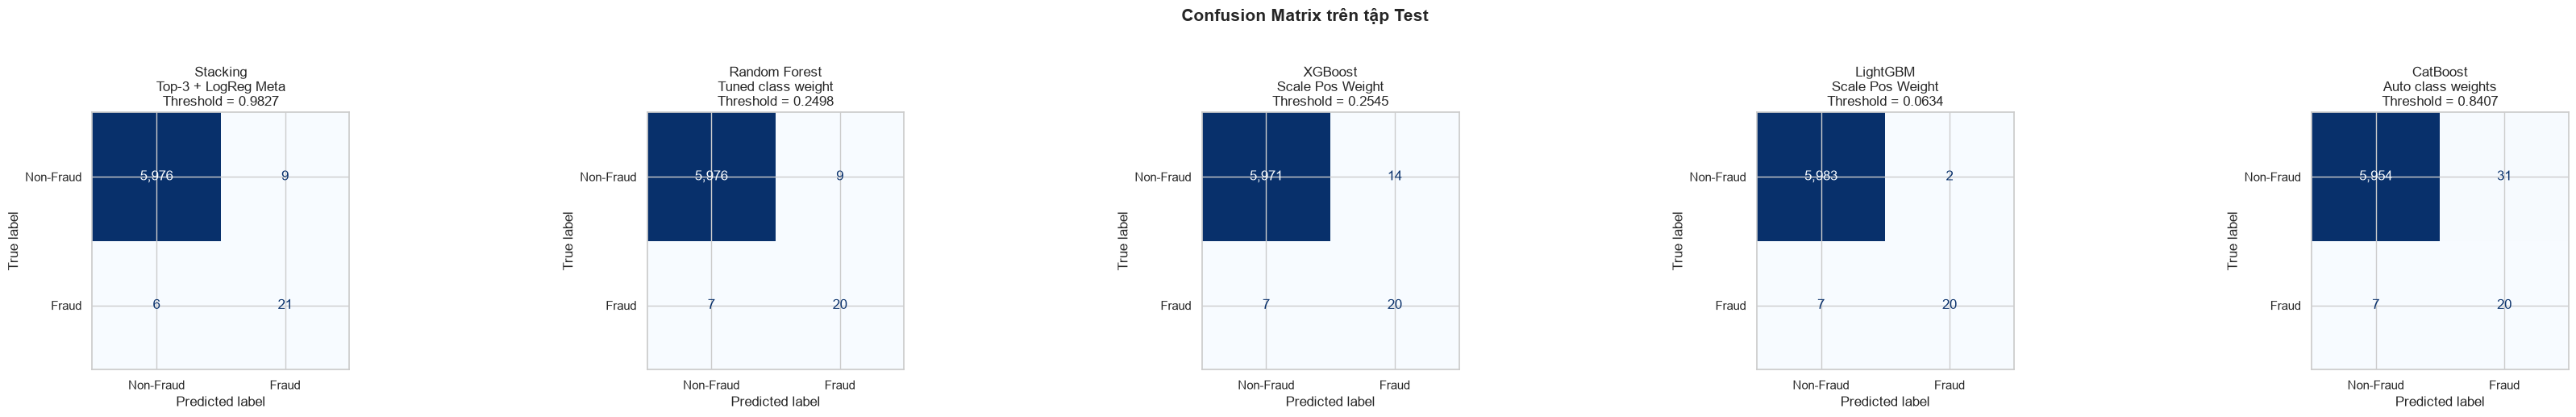

In [ ]:
# =============================================================================
# CONFUSION MATRIX
# =============================================================================
number_of_models = len(test_outputs)
fig, axes = plt.subplots(
    nrows=1,
    ncols=number_of_models,
    figsize=(7 * number_of_models, 5),
)
# Trường hợp chỉ có một model
if number_of_models == 1:
    axes = [axes]

for ax, (model_label, output) in zip(
    axes,
    test_outputs.items(),
):
    cm = confusion_matrix(
        y_test_array,
        output["prediction"],
        labels=[0, 1],
    )

    display_cm = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Non-Fraud",
            "Fraud",
        ],
    )
    display_cm.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format=",d",
    )
    ax.set_title(
        f"{model_label}\n"
        f"Threshold = {output['threshold']:.4f}"
    )

plt.suptitle(
    "Confusion Matrix trên tập Test",
    fontsize=15,
    fontweight="bold",
    y=1.03,
)

plt.tight_layout()
plt.show()

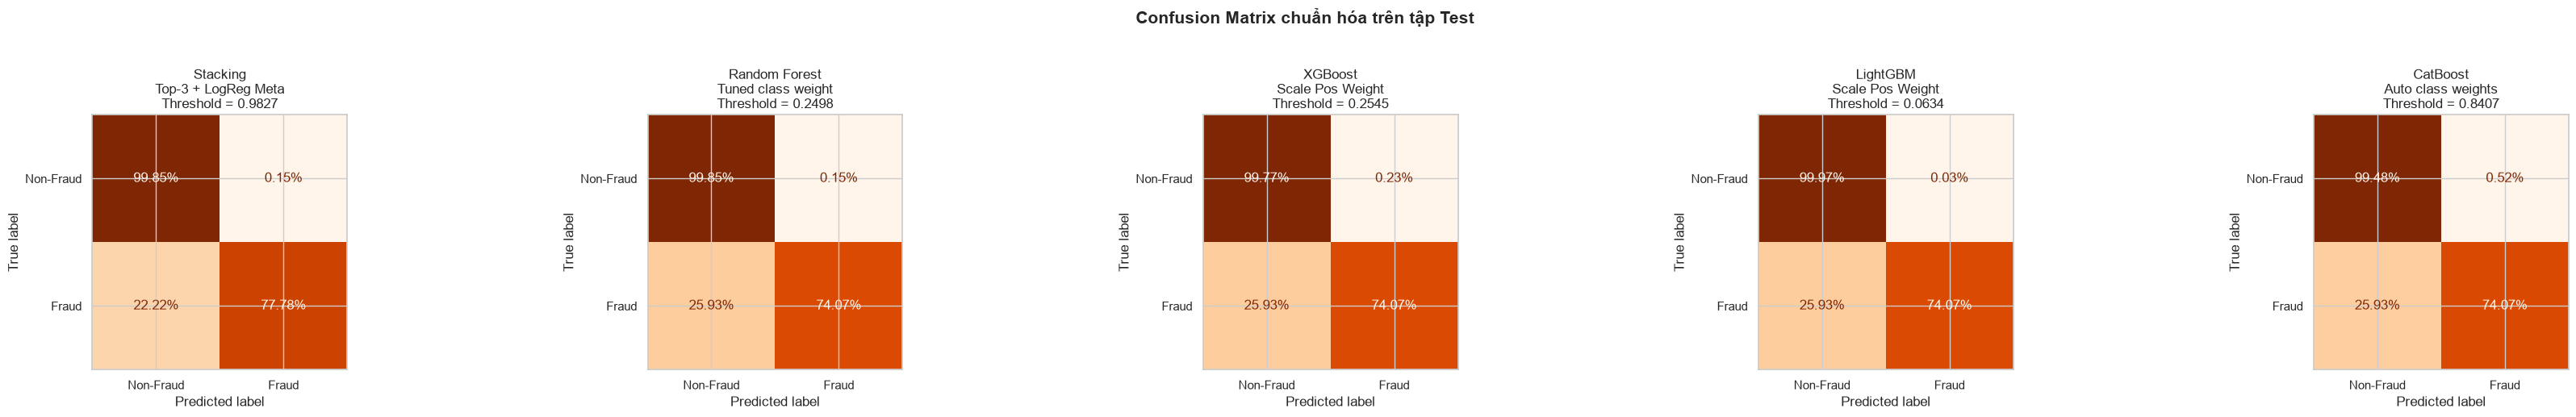

In [ ]:
# =============================================================================
# CONFUSION MATRIX CHUẨN HÓA THEO NHÃN THỰC TẾ
# =============================================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=number_of_models,
    figsize=(7 * number_of_models, 5),
)

if number_of_models == 1:
    axes = [axes]

for ax, (model_label, output) in zip(
    axes,
    test_outputs.items(),
):
    cm_normalized = confusion_matrix(
        y_test_array,
        output["prediction"],
        labels=[0, 1],
        normalize="true",
    )

    display_cm = ConfusionMatrixDisplay(
        confusion_matrix=cm_normalized,
        display_labels=[
            "Non-Fraud",
            "Fraud",
        ],
    )

    display_cm.plot(
        ax=ax,
        cmap="Oranges",
        colorbar=False,
        values_format=".2%",
    )

    ax.set_title(
        f"{model_label}\n"
        f"Threshold = {output['threshold']:.4f}"
    )

plt.suptitle(
    "Confusion Matrix chuẩn hóa trên tập Test",
    fontsize=15,
    fontweight="bold",
    y=1.03,
)

plt.tight_layout()
plt.show()

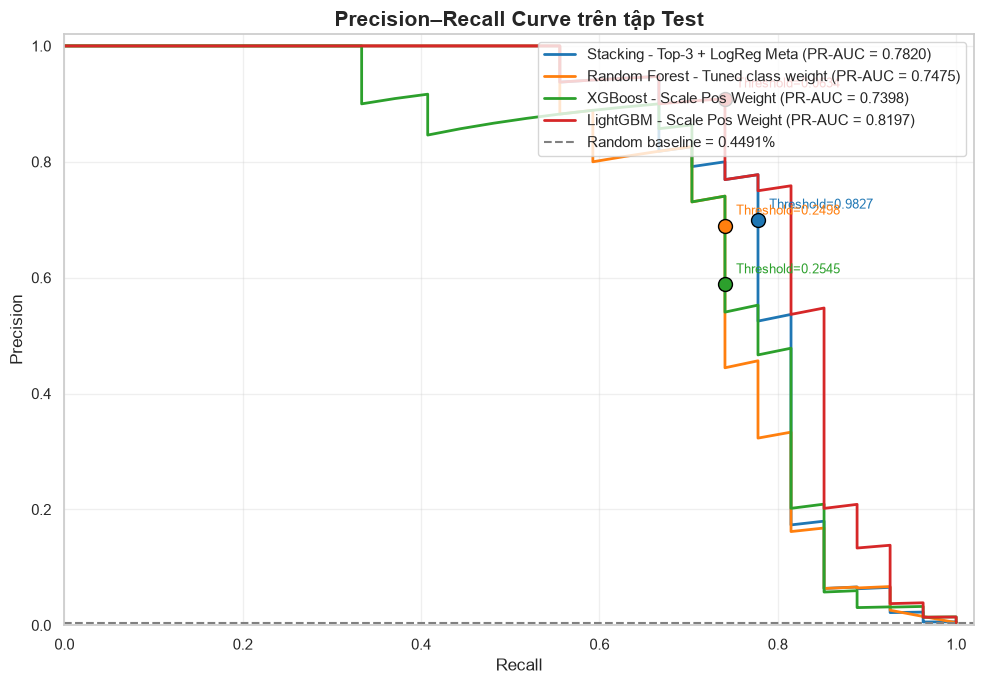

In [ ]:
# =============================================================================
# PRECISION–RECALL CURVE
# =============================================================================

plt.figure(figsize=(10, 7))

colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
]

for color, (model_label, output) in zip(
    colors,
    test_outputs.items(),
):
    curve_precision, curve_recall, curve_thresholds = (
        precision_recall_curve(
            y_test_array,
            output["probability"],
        )
    )

    plt.plot(
        curve_recall,
        curve_precision,
        color=color,
        linewidth=2,
        label=(
            f"{model_label.replace(chr(10), ' - ')} "
            f"(PR-AUC = {output['pr_auc']:.4f})"
        ),
    )

    # Điểm hoạt động tương ứng threshold đã chọn trên Validation
    plt.scatter(
        output["recall_at_threshold"],
        output["precision_at_threshold"],
        color=color,
        s=100,
        edgecolor="black",
        zorder=5,
    )

    plt.annotate(
        f"Threshold={output['threshold']:.4f}",
        xy=(
            output["recall_at_threshold"],
            output["precision_at_threshold"],
        ),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        color=color,
    )


# Baseline = tỷ lệ fraud trong test
fraud_rate_test = np.mean(y_test_array)

plt.axhline(
    y=fraud_rate_test,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Random baseline = "
        f"{fraud_rate_test:.4%}"
    ),
)

plt.title(
    "Precision–Recall Curve trên tập Test",
    fontsize=15,
    fontweight="bold",
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.xlim(0, 1.02)
plt.ylim(0, 1.02)

plt.grid(
    True,
    alpha=0.3,
)

plt.legend(
    loc="upper right",
)

plt.tight_layout()
plt.show()

Model không có attribute feature_importances_.

PERMUTATION IMPORTANCE -- Đánh giá trên Validation Set


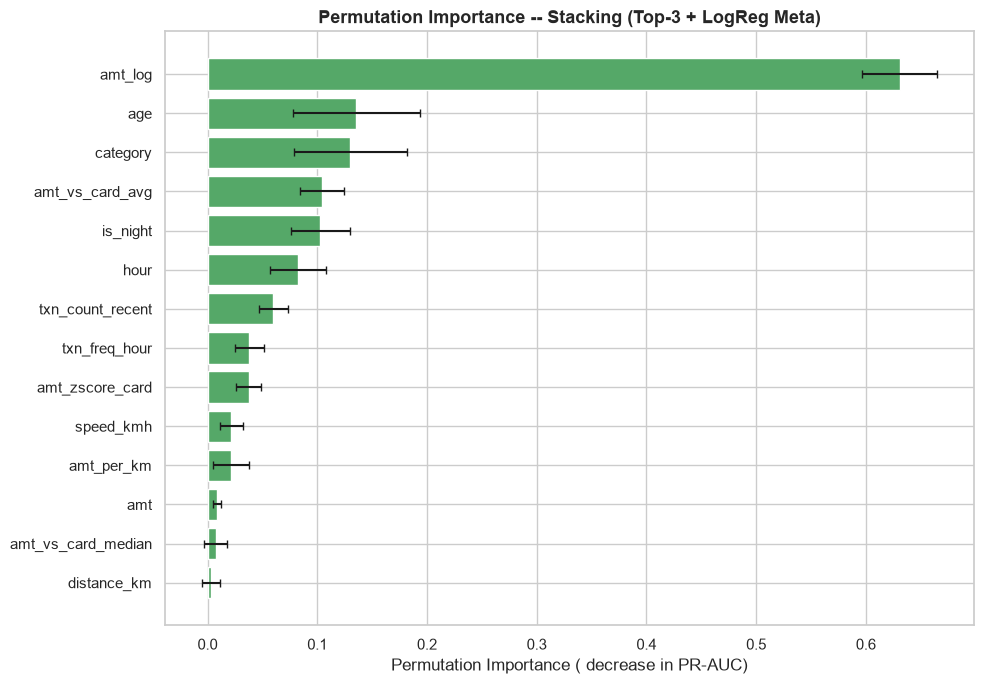


Thời gian tính permutation importance: 11.6s

Top 10 đặc trưng quan trọng nhất (permutation):


,Đặc trưng,Importance (mean),Importance (std)
6,amt_log,0.6309,0.0342
1,age,0.1357,0.0576
13,category,0.1302,0.0518
12,amt_vs_card_avg,0.1042,0.0199
8,is_night,0.1029,0.0266
3,hour,0.0826,0.0258
11,txn_count_recent,0.0600,0.0134
4,txn_freq_hour,0.0381,0.0134
7,amt_zscore_card,0.0374,0.0117
9,speed_kmh,0.0218,0.0106



Permutation importance đáng tin hơn built-in vì:
  - Đo lường chính xác sự sụt giảm performance khi feature bị đảo ngẫu nhiên
  - Hoạt động cho tất cả mô hình, không chỉ riêng mô hình dạng cây (tree-based)


In [ ]:
# =============================================================================
# FEATURE IMPORTANCE -- Tầm quan trọng của từng đặc trưng
# =============================================================================

from sklearn.inspection import permutation_importance

best_model = best_by_model.iloc[0]
best_model_obj = candidate_models[(best_model['Model'], best_model['Imbalance method'])]

# --- 1. Built-in Feature Importance (nếu model hỗ trợ) ---
if hasattr(best_model_obj, 'feature_importances_'):
    importances = best_model_obj.feature_importances_
    importance_df = pd.DataFrame({
        'Đặc trưng': feature_names,
        'Tầm quan trọng': importances,
    }).sort_values('Tầm quan trọng', ascending=True)

    plt.figure(figsize=(10, 7))
    plt.barh(importance_df['Đặc trưng'], importance_df['Tầm quan trọng'], color='#4C72B0')
    plt.xlabel('Feature Importance (gain)')
    plt.title(
        f'Built-in Feature Importance -- {best_model["Model"]} ({best_model["Imbalance method"]})',
        fontsize=13, fontweight='bold',
    )
    plt.tight_layout()
    plt.show()

    print('\nTop 10 đặc trưng quan trọng nhất (built-in):')
    display(importance_df.tail(10).round(4).iloc[::-1])
else:
    print('Model không có attribute feature_importances_.')

# --- 2. Permutation Importance (hoạt động cho TẤT CẢ models) ---
print('\n' + '=' * 80)
print('PERMUTATION IMPORTANCE -- Đánh giá trên Validation Set')
print('=' * 80)

perm_start = time.perf_counter()
perm_result = permutation_importance(
    best_model_obj, X_validation, y_validation,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
    scoring='average_precision',
)
perm_time = time.perf_counter() - perm_start

perm_df = pd.DataFrame({
    'Đặc trưng': feature_names,
    'Importance (mean)': perm_result.importances_mean,
    'Importance (std)': perm_result.importances_std,
}).sort_values('Importance (mean)', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(
    perm_df['Đặc trưng'], perm_df['Importance (mean)'],
    xerr=perm_df['Importance (std)'],
    color='#55A868', capsize=3,
)
plt.xlabel('Permutation Importance ( decrease in PR-AUC)')
plt.title(
    f'Permutation Importance -- {best_model["Model"]} ({best_model["Imbalance method"]})',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
plt.show()

print(f'\nThời gian tính permutation importance: {perm_time:.1f}s')
print('\nTop 10 đặc trưng quan trọng nhất (permutation):')
display(perm_df.tail(10).round(4).iloc[::-1])

print('\nPermutation importance đáng tin hơn built-in vì:')
print('  - Đo lường chính xác sự sụt giảm performance khi feature bị đảo ngẫu nhiên')
print('  - Hoạt động cho tất cả mô hình, không chỉ riêng mô hình dạng cây (tree-based)')




